# Sistema di Face Detection per una fotocamera digitale

### Contesto del Progetto
La **ProCam S.p.A.** è pronta a lanciare una nuova fotocamera digitale compatta, accessibile e pensata per i giovani appassionati di fotografia. L'obiettivo principale del prodotto è facilitare l'esperienza di scatto, in particolare per i selfie con una o più persone.

### Sfida
Sei stato assunto come **Data Scientist** per sviluppare un **sistema di rilevamento volti** nelle immagini, che aiuterà i tecnici a ottimizzare automaticamente le impostazioni della fotocamera durante i selfie. Il tuo compito è realizzare una pipeline che identifichi i volti presenti nelle immagini e restituisca le coordinate dei **bounding box** dove i volti sono individuati. Se non ci sono volti, la pipeline restituirà una lista vuota.

Si tratta di un problema di **Computer Vision**, più precisamente di **Face Detection**.

### Requisiti del Progetto

1. **Obiettivo**: Costruire un sistema di rilevamento dei volti utilizzando **Scikit-learn**. La pipeline deve essere in grado di:
- Prendere un’immagine in ingresso.
- Restituire una lista di coordinate dei bounding box dove sono presenti volti.
- Restituire una lista vuota se nell’immagine non ci sono volti.

2. **Limitazioni**:
- **Dataset**: Non ti viene fornito un dataset. Devi cercare un dataset adatto in rete o, in mancanza di alternative, costruirlo tu stesso.
- **Modelli pre-addestrati**: Non è consentito utilizzare modelli pre-addestrati. Il modello di Face Detection dovrà essere addestrato da zero con Scikit-learn.
- **Risorse di calcolo**: Lavorerai su un sistema con capacità di calcolo limitate. Il modello dovrà essere ottimizzato per utilizzare poche risorse.

3. **Documentazione**: La soluzione deve essere ben documentata. Ogni decisione adottata (scelta degli algoritmi, preprocessamento, tecniche di ottimizzazione) dovrà essere spiegata. Inoltre, ogni risorsa esterna utilizzata (paper accademici, articoli di blog, codice GitHub) dovrà essere citata.

4. **Ricerca bibliografica**: Poiché non ti vengono fornite indicazioni dettagliate sull'implementazione, è essenziale condurre un'approfondita ricerca bibliografica per identificare le soluzioni migliori. Dovrai analizzare approcci già esistenti e adattarli alle limitazioni del progetto.


---------------------------------------

# Scelta del modello

## Support Vector Machine

Come modello di classificazione è stato scelto il Support Vector Machine (SVM), preceduto da una estrazione delle feature con HOG (= Histogram of Oriented Gradients). In questo progetto, con le limitazioni viste, un modello SVM è adatto per:
- essere utilizzato con **Scikit-learn**;
- essere utilizzato con **risorse di calcolo limitate**.
I modelli SVM (in combinazione con HOG) sono stati storicamente utilizzati per object detection classica, e per face detection prima dell'avvento del deep learning. Con un modello SVM non si raggiungeranno le performance ottenute con una rete neurale, ma per i vincoli del progetto è il modello migliore.

Vantaggi di SVM:
- Funziona molto bene con HOG, che produce feature ad alta dimensionalità, sparse e molto informative sui bordi: queste sono ottime feature per il modello SVM.
- Generalizza bene anche con dataset relativamente piccoli.
- Computazionalmente non troppo dispendioso, che è adeguato per questo progetto dove le risorse di calcolo soo limitate.
- Ottime performance binarie nel discriminare tra *face* e *non-face*.

**Fonte**

Dalal e Triggs (2005) hanno introdotto e validato l’approccio basato su HOG + SVM lineare per l'object detection grazie alla loro capacità di rappresentare bordi e gradienti locali dell’immagine.


https://lear.inrialpes.fr/people/triggs/pubs/Dalal-cvpr05.pdf

## Neural Networks

Le reti neurali, in particolare le Convolutional Neural Networks (CNN), sarebbero ottime per la face detection, con delle buone performance, e oggi sono le più utilizzate per questo scopo. Tuttavia in questo progetto vengono escluse perchè:
- si dovrebbe usare una libreria come PyTorch o TensorFlow, ma in questo caso il vincolo è usare Scikit-learn, che non è adatta alle CNN.
- richiedono l'uso di GPU, datset molto grandi (migliaia o milioni di dati) e training lungo, mentre in questo progetto si deve lavorare su un sistema con capacità di calcolo limitate.


## Naive Bayes

I modelli Naive Bayes sono stati esclusi principalmente perchè assumono l'indipendenza tra le feature, ma nè i pixel nè i gradienti HOG sono indiependenti.


## K-Nearest Neighbors

I modelli K-Nearest Neighbors non sono adatti per questo progetto perchè:
- sono molto lenti,
- non funzionano bene con alta dimensionalità,
- non apprendono dai dati ma li memorizzano: deve memorizzazre tutto il training set,
- generalizzazione non molto buona perchè sensibile al rumore


## Logistic Regression

La Logistic Rgression è un modello che potrebbe essere utilizzato perchè:
- è veloce e leggero,
- è compatibile con Scikit-learn,
- è compatibile con HOG.
Logistic Regression produce un boundary lineare simile a una Linear SVM, tuttavia la SVM è più robusta in un problema di Face Detection perchè massimizza il margine di separazione tra le classi.


## Decision Tree

Un Decision Tree potrebbe essere utilizzato perchè:
- molto interpretabile
- training veloce
- compatibile con feature HOG
Tuttavia, l'interpretabilità non è un obiettivo del progetto, e le performance rimangono peggiori rispetto a SVM. Altri problemi potrebbero essere: elevato rischio di overfitting e che piccole variazioni possano causare grandi variazioni nel risultato.

## Random Forest

Come il Decision Tree, anche la Random Forest potrebbe essere utilizzata, con i vantaggi che:
- più robusta dei singoli Decision Tree
- Gestisce feature non lineari
- più resistente all'overfitting rispetto al Decision tree
Tuttavia, rispetto a SVM:
- è più lenta e utilizza più menoria;
- è meno efficace con HOG;
- bounding decision meno puliti: separa meno bene *face* e *non-face*

-----------------------------------

# Scelta del dataset

Il progetto richiede la costruzione di un sistema di face detection basato su SVM e HOG, con l’obiettivo di individuare automaticamente i volti all’interno di immagini contenenti una o più persone, simulando scenari reali come selfie e fotografie di gruppo.

Per questo motivo è necessario un dataset che includa:
- immagini con uno o più volti
- bounding box dei volti già annotati
- variazioni di scala, posa e illuminazione
- contesti realistici ma non eccessivamente complessi, compatibili con modelli classici di machine learning

Dopo una ricerca su Kaggle è stato selezionato il dataset **Face Detection Dataset (di Tushar Anand)** che è adatto a tutti i punti richiesti.

Il dataset è strutturato in due componenti principali: immagini e file di annotazione contenenti le coordinate dei bounding box dei volti

Le immagini sono state raccolte da contesti reali e annotate tramite bounding box che individuano la posizione dei volti.

Questo dataset è stato scelto perché rappresenta un buon compromesso tra complessità realistica del problema e dimensione gestibile su risorse computazionali limitate. Rispetto a dataset più complessi come WIDER FACE, questo dataset consente di evitare scenari eccessivamente difficili, risultando più adatto all’utilizzo di un classificatore SVM.

**Considerazione sull'utilizzo esclusivo di Face Detection Dataset (di Tushar Anand)**

Il dataset Face Detection Dataset fornisce annotazioni accurate dei bounding box dei volti (campioni positivi), ma non include esplicitamente esempi strutturati della classe negativa. Tuttavia, nel contesto di un sistema di face detection basato su sliding window e SVM, la presenza di un dataset esplicito di negativi non è strettamente necessaria.

I campioni negativi vengono infatti generati tramite negative sampling, estraendo regioni casuali delle immagini che non sovrappongono i bounding box dei volti. Per garantire la correttezza dei campioni, viene utilizzata la metrica Intersection over Union (IoU), imponendo una soglia bassa per evitare la selezione di regioni contenenti parti di volto.

Questo garantisce che le patch negative siano realistiche, coerenti con la distribuzione dei dati del dataset e correttamente bilanciate rispetto ai positivi.

**Fonte:**

https://www.kaggle.com/datasets/iamtushara/face-detection-dataset

**Licenza:**

Il dataset è distribuito tramite la piattaforma Kaggle e soggetto ai termini di licenza indicati dall’autore. L’utilizzo è limitato a scopi educativi e non commerciali secondo le policy della piattaforma.

-----------------------------------------

## 1. Importazione di librerie e definizione delle costanti

In [1]:
import zipfile
import os
import cv2
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import imutils
import itertools
import optuna

from tqdm.notebook import tqdm
from skimage.feature import hog
from collections import Counter

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC, SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score

from joblib import Parallel, delayed

In [2]:
RANDOM_SEED = 42

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## 2. Dataset

Il dataset è stato scaricato dalla piattaforma Kaggle -al link sopra riportato- e contiene immagini di volti reali con relative annotazioni dei bounding box. Le immagini sono suddivise in training set e validation set, ciascuno composto da una directory di immagini e una directory di etichette associate.

Ogni immagine possiede un file di annotazione associato contenente le coordinate normalizzate dei bounding box dei volti nel formato YOLO (class_id x_center y_center width height).

Struttura del dataset:

dataset_face_detection/

├── archive.zip

├── archive/

    ├── merged/
        ├── images/
        │   ├── train/
        │   │   ├── image_1.jpg
        │   │   ├── image_2.jpg
        │   │   └── ...
        │   │
        │   ├── validation/
        │       ├── image_1.jpg
        │       ├── image_2.jpg
        │       └── ...
        │
        ├── labels/
            ├── train/
            │   ├── image_1.txt
            │   ├── image_2.txt
            │   └── ...
            │
            ├── validation/
            │   ├── image_1.txt
            │   ├── image_2.txt
            │   └── ...
            │
            ├── train.cache
            └── validation.cache

In [3]:
# cartella che contiene il dataset: 'dataset'
dataset_root = "dataset_face_detection"

In [4]:
# percorso del file zip
zip_path = os.path.join(dataset_root, "archive.zip")

# cartella dove estrarre il dataset
extract_path = os.path.join(dataset_root, "archive")

# estrazione file zip
if not "archive" in os.listdir(dataset_root):
    with zipfile.ZipFile(zip_path, "r") as z:
       z.extractall(extract_path)

print("Dataset estratto correttamente.")

Dataset estratto correttamente.


In [5]:
# PERCORSI PRINCIPALI
merged_dir = os.path.join(dataset_root, "archive", "merged")

# immagini
train_images = os.path.join(merged_dir, "images", "train")
val_images = os.path.join(merged_dir, "images", "validation")

# annotazioni
train_labels = os.path.join(merged_dir, "labels", "train")
val_labels = os.path.join(merged_dir, "labels", "validation")

In [6]:
# verifica estrazione
print(os.listdir(dataset_root))

['archive', 'archive.zip']


## 2.1. Analisi del dataset

Per verificare la struttura del dataset, viene effettuata un’analisi esplorativa delle immagini, con l’obiettivo di:
- controllare il formato delle immagini
- analizzare la distribuzione delle dimensioni (in pixel)
- verificare la presenza di immagini a colori o in scala di grigi
- identificare eventuali immagini corrotte o non valide

Per analizzare le immagini si utilizzano *img.shape* per ottenere dimensioni e numero di canali, e *img.dtype* per verificare il tipo di dato dell’immagine. Se l’immagine è a colori, img.shape restituisce tre dimensioni (altezza, larghezza, canali RGB), mentre per immagini in scala di grigi vengono restituite solo due dimensioni.

Il tipo di dato (dtype) è utile per verificare la consistenza del dataset e l’assenza di formati non standard.

**NOTA**. L'analisi del dataset viene fatta in parallelo per ridurre i tempi di esecuzione.

**Fonte:**

https://docs.opencv.org/3.4/d3/df2/tutorial_py_basic_ops.html


In [10]:
def get_image_paths(root_dir):
    """
    Funzione che esplora ricorsivamente tutte le sottocartelle presenti nella directory root_dir 
    e raccoglie i percorsi completi di tutte le immagini.

    Parametri:
    - root_dir (str): percorso della cartella principale del dataset.

    Output:
    - image_paths (list): lista contenente i percorsi completi di tutte le immagini trovate nel dataset.
    """
    
    image_paths = [] # lista vuota per salvare il percorso completo di ogni immagine

    # esplorazione delle cartelle: la funzione os.walk() serve per attraversare automaticamente tutte le cartelle, incluse le sottocartelle
    # e restitusce per ogni cartella:
    # - il percorso della cartella corrente: dirpath
    # - la lista dei file presenti nella cartella corrente: filenames

    for dirpath, _, filenames in os.walk(root_dir):
        for file in filenames:   # ciclo su tutti i file
            if file.lower().endswith(('.jpg', '.jpeg', '.png')): # controllo estensione dell'immagine ec onverte tutto in minuscolo
                image_paths.append(os.path.join(dirpath, file))  # creazione del percorso completo e salvataggio nella lista image_paths

    return image_paths

In [11]:
# PATH DATASET
merged_dir = os.path.join(dataset_root, "archive", "merged")

train_images = os.path.join(merged_dir, "images", "train")
val_images = os.path.join(merged_dir, "images", "validation")

train_paths = get_image_paths(train_images)
val_paths = get_image_paths(val_images)

In [12]:
def _analyze_one_image(path, check_empty=True, resize_for_std=64):
    """
    Funzione che analizza una singola immagine e serve per la funzione analyze_dataset_fast.

    Parametri:
    - path (str): percorso all'immagine
    - check_empty (bool): se True controlla immagini "vuote" (std < 5)
    - resize_for_std (int): dimensione del thumbnail per stimare std

    Output:
    - dict con campi: path, status ("unreadable"|"too_small"|"almost_empty"|"ok")
      e (se status=="ok") h, w, area, is_color, dtype
    """
    img = cv2.imread(path, cv2.IMREAD_UNCHANGED)
    if img is None:
        return {"path": path, "status": "unreadable"}

    h, w = img.shape[:2]
    if h < 20 or w < 20:
        return {"path": path, "status": "too_small"}

    if check_empty:
        small = cv2.resize(img, (resize_for_std, resize_for_std),
                           interpolation=cv2.INTER_AREA)
        if np.std(small) < 5:
            return {"path": path, "status": "almost_empty"}

    if len(img.shape) == 2:
        is_color = False
    elif len(img.shape) == 3 and img.shape[2] >= 3:
        is_color = True
    else:
        is_color = False

    return {
        "path": path,
        "status": "ok",
        "h": h,
        "w": w,
        "area": h * w,
        "is_color": is_color,
        "dtype": str(img.dtype),
    }


def analyze_dataset_fast(image_paths,
                         check_empty=True,
                         resize_for_std=64,
                         n_jobs=-1):
    """
    Analizza un insieme di immagini in PARALLELO e produce statistiche sul dataset.

    Implementazione: distribuisce i percorsi delle immagini su un pool di thread
    via joblib (`Parallel(prefer="threads")`). Le chiamate cv2.imread/resize
    rilasciano il GIL, quindi i thread scalano efficacemente con il numero di core
    senza overhead di pickle (rispetto a multi-processing).
    Le statistiche di aggregazione (smallest/largest, color info, ecc.) sono
    calcolate in modo vettorializzato dopo aver raccolto i risultati dei worker.

    Parametri:
    - image_paths (list): lista di percorsi alle immagini
    - check_empty (bool): se True scarta immagini quasi vuote (std < 5) (default True)
    - resize_for_std (int): dimensione thumbnail per calcolo std (default 64)
    - n_jobs (int): worker paralleli (default -1 = tutti i core disponibili)

    Output:
    - dict con campi: smallest_image, smallest_dimension, largest_image,
                      largest_dimension, color_info, image_types,
                      num_unreadable_images, num_too_small_images,
                      num_almost_empty_images, unreadable_images[:20],
                      too_small_images[:20], almost_empty_images[:20]
    """
    # esecuzione parallela: thread-backend perche' l'I/O cv2 rilascia il GIL
    results = Parallel(n_jobs=n_jobs, prefer="threads", verbose=0)(
        delayed(_analyze_one_image)(p, check_empty, resize_for_std)
        for p in image_paths
    )

    # split dei risultati per status
    unreadable   = [r["path"] for r in results if r["status"] == "unreadable"]
    too_small    = [r["path"] for r in results if r["status"] == "too_small"]
    almost_empty = [r["path"] for r in results if r["status"] == "almost_empty"]
    valid        = [r for r in results if r["status"] == "ok"]

    # aggregazione vettorializzata su immagini valide
    if valid:
        areas = np.array([r["area"] for r in valid])
        smallest_idx = int(areas.argmin())
        largest_idx  = int(areas.argmax())

        smallest = valid[smallest_idx]
        largest  = valid[largest_idx]

        smallest_image     = os.path.basename(smallest["path"])
        smallest_dimension = (smallest["h"], smallest["w"])
        largest_image      = os.path.basename(largest["path"])
        largest_dimension  = (largest["h"], largest["w"])

        all_color = all(r["is_color"] for r in valid)
        all_bw    = all(not r["is_color"] for r in valid)
        image_types = sorted({r["dtype"] for r in valid})

        if all_color and not all_bw:
            color_info = "tutte a colori"
        elif all_bw and not all_color:
            color_info = "tutte in bianco e nero"
        else:
            color_info = "sia a colori che in bianco e nero"
    else:
        smallest_image = smallest_dimension = None
        largest_image  = largest_dimension  = None
        color_info     = "nessuna immagine valida"
        image_types    = []

    return {
        "smallest_image": smallest_image,
        "smallest_dimension": smallest_dimension,
        "largest_image": largest_image,
        "largest_dimension": largest_dimension,
        "color_info": color_info,
        "image_types": image_types,
        "num_unreadable_images": len(unreadable),
        "num_too_small_images": len(too_small),
        "num_almost_empty_images": len(almost_empty),
        "unreadable_images": unreadable[:20],
        "too_small_images": too_small[:20],
        "almost_empty_images": almost_empty[:20],
    }

In [13]:
def print_dataset_report(result):

    """
    Funzione che stampa un report descrittivo delle caratteristiche del dataset 
    a partire dal dizionario prodotto dalla funzione analyze_dataset().
    
    Il report mostra:
    - il percorso dell'immagine con dimensione minore e le sue dimensioni;
    - il percorso dell'immagine con dimensione maggiore e le sue dimensioni;
    - informazioni sulla composizione del dataset rispetto al colore delle immagini
      (tutte a colori, tutte in bianco e nero oppure miste);
    - i tipi di dato delle immagini presenti nel dataset.
    
    Parametri:
    - result (dict): dizionario contenente le informazioni restituite dalla funzione analyze_dataset().
    
    Output:
    - stampa a video del report finale del dataset.
    """

    print(f"L'immagine con dimensione minore è:")
    print(f"{result['smallest_image']}")
    h, w = result["smallest_dimension"]
    print(f"Dimensione: {h} x {w} pixel\n")

    print(f"L'immagine con dimensione maggiore è:")
    print(f"{result['largest_image']}")
    h, w = result["largest_dimension"]
    print(f"Dimensione: {h} x {w} pixel\n")

    print(f"Le immagini sono: {result['color_info']}.\n")

    print(f"Tipi di immagini trovati:")
    print(result['image_types'])

In [11]:
dataset_report = analyze_dataset_fast(train_paths)
print_dataset_report(dataset_report)

L'immagine con dimensione minore è:
11191.jpeg
Dimensione: 171 x 1024 pixel

L'immagine con dimensione maggiore è:
1435402a913fb5ee.jpg
Dimensione: 3456 x 4608 pixel

Le immagini sono: sia a colori che in bianco e nero.

Tipi di immagini trovati:
['uint8']


**--> NOTA. Nel dataset non ci sono immagini non leggibili o corrotte.**

## 2.2. PARSING DELLE ANNOTAZIONI

Le annotazioni del dataset sono fornite in file .txt associati a ciascuna immagine. Ogni file contiene le informazioni relative ai bounding box dei volti presenti nell’immagine.


Esempio del primo file di annotazione:

In [12]:
# prendo una immagine qualsiasi
image_path = get_image_paths(train_images)[0]

# ricavo il nome del file senza estensione
filename = os.path.splitext(os.path.basename(image_path))[0]

# costruisco il path del file di annotazione
label_path = os.path.join(train_labels, filename + ".txt")

# apertura e lettura file
with open(label_path, "r") as f:
    lines = f.readlines()

# stampa contenuto grezzo
print("\n=== CONTENUTO FILE TXT ===\n")

for i, line in enumerate(lines[:20]):  # prime 20 righe
    print(line.strip())


=== CONTENUTO FILE TXT ===

0 0.498046875 0.292057761732852 0.119140625 0.10758122743682311


**Commento del risultato** 

Il file di annotazione visualizzato contiene una singola riga nel formato YOLO standard:
- class_id --> è la classe del bounding box, che rappresenta la classe face, in questo caso 0
- x_center --> coordinata X del centro del volto
- y_center --> coordinata Y del centro del volto
- width --> larghezza del bounding box
- height --> altezza del bounding box

Tutti i valori sono normalizzati (tra 0 e 1) rispetto alle dimensioni dell’immagine.

Per poter utilizzare queste informazioni nel processo di addestramento del modello SVM, è necessario convertire le annotazioni in un formato utilizzabile dal pipeline di machine learning.

Durante questa fase, ogni immagine viene associata ai relativi bounding box convertiti in coordinate pixel.

Successivamente, le immagini vengono caricate tramite OpenCV e organizzate in una struttura dati del tipo:

dataset = [(image_path, boxes), ... ]

dove:
- image_path rappresenta il percorso completo dell’immagine;
- boxes rappresenta la lista dei bounding box associati all’immagine.

Questa struttura permette di accedere in modo semplice e diretto sia ai dati dell’immagine sia alle relative annotazioni, facilitando la successiva costruzione del dataset patch-based utilizzato per il training del classificatore.

## 2.3. Limitazioni del dataset: esclusione delle immagini con troppi volti

Un modello classico di Machine Learning — come HOG + LinearSVC — ha capacità rappresentative molto più limitate rispetto a un approccio Deep Learning.

Nelle immagini affollate con molti volti ravvicinati (concerti, manifestazioni, eventi sportivi):
- i bounding box positivi si sovrappongono, rendendo difficile il ritaglio pulito delle patch
- le patch negative estratte nelle zone di sfondo contengono spesso teste parziali, profili o corpi che il classificatore fatica a distinguere da volti veri
- il rapporto segnale/rumore del training set peggiora, generando più falsi positivi al momento dell'inference

Per questo motivo è stato scelto di **limitare il dataset a immagini con meno di 4 volti**, eliminando le scene di folla. Di seguito viene controllato che con questa limitazione il dataset rimanga sufficientemente grande.

In [14]:
train_labels_dir = os.path.join(dataset_root, "archive", "merged", "labels", "train")
val_labels_dir   = os.path.join(dataset_root, "archive", "merged", "labels", "validation")

def count_faces_per_image(labels_dir):
    counts = []
    for fname in os.listdir(labels_dir):
        if not fname.endswith(".txt"):
            continue
        fpath = os.path.join(labels_dir, fname)
        with open(fpath, "r", encoding="utf-8") as f:
            n = sum(1 for line in f if len(line.strip().split()) == 5)
        counts.append(n)
    return counts

MAX_FACES = 4  # soglia scelta per il filtraggio

train_counts = count_faces_per_image(train_labels_dir)
val_counts   = count_faces_per_image(val_labels_dir)

for split, counts in [("TRAIN", train_counts), ("VAL", val_counts)]:
    total  = len(counts)
    kept   = sum(1 for c in counts if c < MAX_FACES)
    discarded = total - kept
    print(f"=== {split} ===")
    print(f"  Totale immagini:             {total:6,}")
    print(f"  Conservate (< {MAX_FACES} volti):  {kept:6,}  ({kept/total*100:.1f}%)")
    print(f"  Scartate   (>= {MAX_FACES} volti): {discarded:6,}  ({discarded/total*100:.1f}%)")
    print()

=== TRAIN ===
  Totale immagini:             26,266
  Conservate (< 4 volti):  17,299  (65.9%)
  Scartate   (>= 4 volti):  8,967  (34.1%)

=== VAL ===
  Totale immagini:              6,573
  Conservate (< 4 volti):   4,291  (65.3%)
  Scartate   (>= 4 volti):  2,282  (34.7%)



**Interpretazione dei risultati**

L'analisi conferma che circa il **66% del dataset** contiene meno di 4 volti per immagine, una quantità sufficiente per questo progettp di face detection. Eliminare le immagini di folla rende il confine decisionale della SVM più netto e riduce i falsi positivi durante l'inference, senza penalizzare in modo significativo la quantità di campioni disponibili per il training.

In [15]:
def load_annotations(image_dir, labels_dir, max_images=None, max_faces=None):

    """
    Funzione che costruisce un dataset per face detection a partire da un dataset in formato YOLO.

    Il dataset è organizzato in due directory:
    - image_dir: contiene le immagini (train/validation)
    - labels_dir: contiene i file .txt associati a ciascuna immagine
    
    Ogni file di annotazione è nel formato YOLO:
    - class_id x_center y_center width height (valori normalizzati)
    
    La funzione esegue le seguenti operazioni:
    1. associa ogni immagine al relativo file di annotazione
    2. legge i bounding box dal file .txt
    3. converte le coordinate YOLO normalizzate in coordinate pixel (x, y, w, h)
    4. costruisce una struttura dati utilizzabile per il training
    
    La funzione NON utilizza modelli pre-addestrati e NON memorizza immagini in memoria,
    ma lavora solo su path e annotazioni per ridurre il consumo di RAM.
    
    Parametri:
    - image_dir (str): directory contenente le immagini
    - labels_dir (str): directory contenente i file di annotazione .txt
    - max_images (int, opzionale): limite massimo di immagini da processare (utile per debug)
    - max_faces (int, opzionale): se impostato, esclude le immagini con >= max_faces volti;
      utile per eliminare scene di folla che degradano le feature HOG e aumentano i falsi positivi

    Output:
    - dataset (list): lista di tuple (image_path, boxes)
      dove boxes è una lista di bounding box nel formato (x, y, w, h) in pixel
    """

    dataset = []
    
    image_paths = get_image_paths(image_dir)

    for image_path in image_paths:

        # nome file senza estensione
        filename = os.path.splitext(os.path.basename(image_path))[0]

        label_path = os.path.join(labels_dir, filename + ".txt")

        # se non esiste label, skip
        if not os.path.exists(label_path):
            continue

        # FIX: legge il file di label PRIMA di caricare l'immagine;
        # se l'immagine ha troppi volti la salta senza sprecare RAM/I/O
        with open(label_path, "r") as f:
            lines = f.readlines()

        valid_lines = [l for l in lines if len(l.strip().split()) == 5]

        if max_faces is not None and len(valid_lines) >= max_faces:
            continue  # scarta immagini con troppe facce (es. scene di folla)

        img = cv2.imread(image_path)

        if img is None:
            continue

        h_img, w_img = img.shape[:2]

        boxes = []

        for line in valid_lines:

            parts = line.strip().split()

            # YOLO format:
            # class x_center y_center width height

            _, x_c, y_c, w, h = map(float, parts)

            # conversione da YOLO normalizzato a pixel
            x = int((x_c - w / 2) * w_img)
            y = int((y_c - h / 2) * h_img)

            w = int(w * w_img)
            h = int(h * h_img)

            if w > 0 and h > 0:
                boxes.append((x, y, w, h))

        dataset.append((image_path, boxes))

        if max_images and len(dataset) >= max_images:
            break

    return dataset


In [16]:
# CREAZIONE DATASET ridotti per debug e tuning veloce
# e controllo struttura del dataset
# FIX: max_faces=4 esclude le immagini con >= 4 volti (scene di folla),
#      che degradano le feature HOG e generano falsi positivi nell'addestramento

train_dataset = load_annotations(
    train_images,
    train_labels,
    max_images=1000,
    max_faces=4
)

val_dataset = load_annotations(
    val_images,
    val_labels,
    max_images=1000,
    max_faces=4
)

print("Train size:", len(train_dataset))

image_path, boxes = train_dataset[0]

print("Image:", image_path)
print("Num boxes:", len(boxes))
print("First box:", boxes[0] if boxes else None)

Train size: 1000
Image: dataset_face_detection\archive\merged\images\train\0.jpeg
Num boxes: 1
First box: (449, 330, 122, 149)


**Controllo della struttura del dataset (train)**

Il dataset è stato costruito correttamente a partire dal formato YOLO e risulta organizzato come una lista di campioni.

Ogni campione è una tupla della forma: (image_path, boxes)
dove:
- image_path rappresenta il percorso completo dell’immagine nel dataset
- boxes è una lista di bounding box associati all’immagine

Il dataset di training contiene 1000 immagini.

Esempio per la prima immagine:
- contiene 1 bounding box
- il bounding box è rappresentato nel formato (x, y, w, h), dove:
  -  x e y sono le coordinate dell’angolo in alto a sinistra del bounding box
  -  w è la larghezza del volto in pixel
  -  h è l'altezza del volto in pixel

## 2.4. Negative sampling

La tecnica chiamata negative sampling viene utilizzata per costruire esempi appartenenti alla classe “non-volto”, necessari per addestrare un classificatore binario in grado di distinguere tra regioni dell’immagine che contengono un volto e regioni di sfondo. 

Nel dataset utilizzato (face detection dataset in formato YOLO), sono presenti esclusivamente annotazioni relative ai volti (classe positiva), mentre non esiste una classe esplicita per le regioni negative.

Per questo motivo, i campioni negativi vengono estratti casualmente dalle immagini e filtrati tramite la metrica Intersection over Union (IoU), in modo da escludere tutte le patch che presentano una sovrapposizione significativa con i bounding box dei volti. 

In particolare, IoU serve a misurare quanto due rettangoli si sovrappongono:
- box A = volto vero (ground truth)
- box B = patch che si sta creando
Un valore di IoU vicino a 0 indica che le due regioni non si sovrappongono, mentre valori alti indicano forte sovrapposizione.

Questo processo garantisce la costruzione di un dataset più pulito e bilanciato, riducendo il rischio di etichettare erroneamente porzioni contenenti volti come negativi e migliorando così la capacità di generalizzazione del modello.

**Fonte**

https://lear.inrialpes.fr/people/triggs/pubs/Dalal-cvpr05.pdf

In [17]:
def iou(boxA, boxB):
    """
    Funzione per calcolare la Intersection over Union (IoU) tra due bounding box.

    Parametri:
    - boxA (tuple): (x, y, w, h)
    - boxB (tuple): (x, y, w, h)

    Output:
    - float: valore IoU compreso tra 0 e 1
    """
    
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[0] + boxA[2], boxB[0] + boxB[2])
    yB = min(boxA[1] + boxA[3], boxB[1] + boxB[3])

    inter_area = max(0, xB - xA) * max(0, yB - yA)

    areaA = boxA[2] * boxA[3]
    areaB = boxB[2] * boxB[3]

    union_area = areaA + areaB - inter_area

    if union_area == 0:
        return 0

    return inter_area / union_area

## 3. Preprocessing: Resize e conversione in grayscale

Durante l’analisi esplorativa del dataset WIDER FACE è emerso che le immagini hanno dimensioni molto variabili (da circa 171×1024 pixel fino a 9108×1024 pixel) e sono a colori (RGB).

Per poter utilizzare un classificatore basato su HOG + SVM è necessario rendere i dati uniformi tramite una fase di preprocessing.

**Resize**

Il resize è un passaggio fondamentale perché il sistema lavora su patch di dimensione fissa, requisito necessario per:
- l’estrazione di feature HOG (vettore di lunghezza costante)
- l’addestramento del classificatore SVM
- il successivo utilizzo in sliding window per la face detection

In questo progetto tutte le patch vengono ridimensionate a 64×64 pixel.
La scelta di 64×64 è stata preferita a 64×128 per ridurre il costo computazionale e perché le facce nel dataset WIDER FACE sono spesso già quasi quadrate.



**Conversione in grayscale**

Si convertono le immagini in scala di grigi perchè:
- il colore non è informativo per la face detection classica basata su gradienti;
- si riduce la dimensionalità (da 3 canali RGB a 1);
- si migliora la generalizzazione del modello.

**Data augmentation**

Data augmentation è utile se:
- il dataset è piccolo o sbilanciato;
- si usa una tecnica di deep learning.
Tuttavia in questo caso il dataset è già grande e la tecnica di SVM non è di deep learning, quindi non è indispensabile fare data augmentation.
Per questi motivi e per facilità computazionale (richiesta del progetto) è stato scelto di non fare data augmentation.


**Normalizzazione**

Non è necessaria la normalizzazione delle immagini prima dell’estrazione delle feature HOG, poiché l’algoritmo HOG include già al proprio interno un processo di **normalizzazione** dei blocchi (L2-Hys) che rende le feature robuste rispetto a variazioni di illuminazione e contrasto. 

Tuttavia è fondamentale che le feature in input per il classificatore SVM siano standardizzate, quindi la **standardizzazione** verrà fatta successivamente: sulle feature estratte tramite HOG.


**NOTA.** Il preprocessing e l’estrazione delle feature non vengono implementati tramite una pipeline di scikit-learn, ma attraverso funzioni modulari riutilizzabili.

Questo consente una maggiore efficienza computazionale e una migliore gestione della memoria RAM, perchè consente di evitare di mantenere grandi quantità di dati intermedi in memoria durante la costruzione del dataset.

La modularità delle funzioni garantisce inoltre chiarezza del codice e riusabilità nei successivi step del progetto (es. sliding window detection).

In [18]:
def preprocess_patch(patch, size=(64, 64)):
    """
    Funzione che applica preprocessing a una patch dell'immagine.

    Operazioni:
    - resize a dimensione fissa
    - conversione in scala di grigi

    Parametri:
    - patch (np.array): immagine in formato BGR
    - size (tuple): dimensione target (width, height)

    Output:
    - gray (np.array): immagine in scala di grigi
    """
    resized = cv2.resize(patch, size)
    gray = cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)) 
      # CLAHE migliora il contrasto locale e aiuta HOG su volti in condizioni di luce variabile. 
    gray_clahe = clahe.apply(gray)
    return gray_clahe

## 4. Feature extraction con HOG

Si utilizza **HOG (Histogram of Oriented Gradients)**, una delle tecniche più classiche per la rappresentazione di immagini in problemi di computer vision, in particolare per face detection e object detection pre-deep learning.

HOG è un metodo di estrazione di feature basato sull’analisi dei gradienti dell’immagine: descrive la forma degli oggetti attraverso la distribuzione delle direzioni dei bordi, ignorando in parte l’informazione di colore e intensità assoluta.

Questo lo rende particolarmente efficace per il riconoscimento di volti, dove la struttura (occhi, naso, bocca) è più importante della luminosità.

Il processo di funzionamento di HOG si articola in quattro fasi principali:

**1. Calcolo dei gradienti** _ Per ogni pixel dell'immagine vengono calcolate le variazioni di intensità in verticale e in orizzontale. Questo permette di evidenziare bordi, contorni e forme.
   
**2. Suddivisione in celle** _ L’immagine viene divisa in piccole regioni chiamate celle (es. 8×8 pixel) e dentro ogni cella si analizzano i gradienti.

**3. Istogramma delle direzioni** _ Per ogni cella si crea un istogramma che indica in che direzione puntano i gradienti (vertical, orizzontale, diagonale). Questo permette di catturare la "forma locale" dell'oggetto.

**4. normalizzazione a blocchi** _ Le celle vengono raggruppate in blocchi (es. 2×2 celle) e normalizzate. Questo serve a rendere il descrittore robusto a cambi di illuminazione, ombre e contrasto.

Il risultato finale è un vettore numerico che rappresenta la struttura del volto.

**Fonte**

https://scikit-image.org/docs/0.25.x/auto_examples/features_detection/plot_hog.html

In [19]:
def extract_hog(gray_img, orientations=9, pixels_per_cell=(8,8), cells_per_block=(2,2)):
    """
    Funzione per l'estrazione feature HOG (Histogram of Oriented Gradients) da un'immagine in scala di grigi.

    Parametri:
    - gray_img (np.array): immagine 2D in scala di grigi
    - orientations (int): numero di bin per gli istogrammi delle orientazioni dei gradienti
    - pixels_per_cell (tuple): dimensione della cella (in pixel) per il calcolo degli istogrammi
    - cells_per_block (tuple): numero di celle per blocco utilizzato per la normalizzazione

    Output:
    - features (np.array): vettore monodimensionale contenente le feature HOG estratte
    """
    return hog(
        gray_img,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block,
        block_norm="L2-Hys",
        feature_vector=True
    )

## 5. Costruzione del dataset patch based

In questa fase viene costruito il dataset utilizzato per l’addestramento del classificatore SVM.

Il dataset non viene utilizzato a livello di immagine completa, ma viene trasformato in un insieme di patch (sotto-regioni locali dell’immagine).

Per ogni immagine vengono quindi estratti due tipi di campioni:
- **campioni positivi**, ottenuti ritagliando le regioni corrispondenti ai bounding box dei volti forniti dalle annotazioni;
- **campioni negativi**, ottenuti tramite campionamento casuale di regioni dell’immagine che non si sovrappongono ai volti, verificato tramite la metrica Intersection over Union (IoU).

Ogni patch viene poi sottoposto a:
- preprocessing (resize e conversione in scala di grigi);
- estrazione delle feature HOG (Histogram of Oriented Gradients).

In questo modo ogni immagine viene trasformata in un insieme di vettori numerici rappresentativi, che verranno utilizzati per addestrare il classificatore SVM.

**NOTA**. La costruzione del dataset avviene in modalità on-the-fly: le immagini non vengono memorizzate in memoria, ma vengono lette, processate e convertite direttamente in feature numeriche. Questo approccio consente di ridurre significativamente il consumo di RAM e rendere il sistema scalabile anche su dataset di grandi dimensioni come WIDER FACE.

In [20]:
def build_hog_dataset(dataset, 
                      patch_w=64, 
                      patch_h=64, 
                      neg_per_image=3, 
                      orientations=9,
                      pixels_per_cell=(8, 8),
                      cells_per_block=(2, 2),
                      seed=RANDOM_SEED):
    """
    Funzione che costruisce il dataset per il training del classificatore SVM.
    
    Per ogni immagine del dataset:
    - estrae campioni positivi (patch contenenti volti);
    - genera campioni negativi (patch NON contenenti volti);
    - applica preprocessing: resize + conversione grayscale;
    - estrae feature HOG.
        
    Parametri:
    - dataset (list): lista nel formato: [(image_path, boxes), ...]
    - patch_w (int): larghezza delle patch
    - patch_h (int): altezza delle patch
    - neg_per_image (int): numero di patch negative da generare per immagine
    - orientations (int): numero di orientazioni per HOG
    - pixels_per_cell (tuple): dimensione cella per HOG
    - cells_per_block (tuple): numero di celle per blocco HOG
    - seed (int): per la ripoducibilità
    
    Output:
    - X (numpy.ndarray): matrice feature HOG
    - y (numpy.ndarray): vettore etichette (1 = face, 0 = non-face)
    """
    
    random.seed(seed)
    X = []
    y = []

    for image_path, boxes in dataset:

        # 1. CARICAMENTO DELL'IMMAGINE
        
        image = cv2.imread(image_path)

        if image is None:
            continue

        h_img, w_img = image.shape[:2]

        # controllo dimensione
        if w_img < patch_w or h_img < patch_h:
            continue

        
        # 2. POSITIVE SAMPLES
        for (x, y_box, w, h) in boxes:

            # filtro per scartare le facce troppo piccole
            if w < 20 or h < 20:
                continue

            # estrazione volto
            face = image[y_box:y_box + h, x:x + w]

            if face.size == 0:
                continue

            # Chiamata della funzione per il PREPROCESSING
            gray = preprocess_patch(face, (patch_w, patch_h))

            # Chiamata della funzione per la feature extraction con HOG + VISUALIZZAZIONE
            features = extract_hog(
                gray,
                orientations=orientations,
                pixels_per_cell=pixels_per_cell,
                cells_per_block=cells_per_block)
            
            X.append(features)
            y.append(1)


        
        # 3. NEGATIVE SAMPLES
        
        for _ in range(neg_per_image):

            for _ in range(10):

                x_rand = random.randint(0, w_img - patch_w)
                y_rand = random.randint(0, h_img - patch_h)

                patch_box = (x_rand, y_rand, patch_w, patch_h)

                overlap = False

                # controllo IoU
                for (x, y_box, w, h) in boxes:
                    if iou(patch_box, (x, y_box, w, h)) > 0.1:
                        overlap = True
                        break

                if not overlap:

                    # patch negativa
                    patch = image[y_rand:y_rand+patch_h, x_rand:x_rand+patch_w]

                    if patch.size == 0:
                        continue

                    # Chiamata della funzione per il PREPROCESSING
                    gray = preprocess_patch(patch, (patch_w, patch_h))

                    # Chiamata della funzione per la feature extraction con HOG
                    features = extract_hog(gray,
                                           orientations=orientations,
                                           pixels_per_cell=pixels_per_cell,
                                           cells_per_block=cells_per_block)

                    X.append(features)
                    y.append(0)

                    break

    return np.array(X), np.array(y)

In [21]:
# DATASET RIDOTTO per tuning veloce
train_data = train_dataset  # già limitato da max_images nel caricamento
val_data = val_dataset[:800]

**Controllo che il dataset non sia troppo sbilanciato**

In [21]:
# --------------------- CONTROLLO ------------

# COSTRUZIONE FEATURE HOG
X_train, y_train = build_hog_dataset(train_data)

X_val, y_val = build_hog_dataset(val_data)

# CONTROLLO DISTRIBUZIONE CLASSI
print("TRAIN DISTRIBUTION:", np.bincount(y_train))
print("VAL DISTRIBUTION:", np.bincount(y_val))

TRAIN DISTRIBUTION: [3000 1491]
VAL DISTRIBUTION: [2400 1206]


Non c'è uno sbilanciamento severo che possa compromettere le performance, solo uno sbilancimento moderato di circa 2:1 tra classe negativa (non-face) e classe positiva (face).

## 6. Visualizzazione della feature estraction
Di seguito viene mostrata una visualizzazione per verificare le fasi di preprocessing e di feature extraction.
Per alcuni esempi del dataset vengono mostrate:
- Immagine originale con bounding box;
- Face patch (cioè il ritaglio del volto delimitato dalla bounding box) preprocessato (grayscale, 64x64);
- Rappresentazione HOG: la visualizzazione evidenzia la distribuzione dei gradienti locali, permettendo di osservare chiaramente contorni strutturali del volto (occhi, naso, bocca).

Visualizzazione di immagini, con bounding box reali, face patch e rappresentazione HOG.


In [22]:
def visualize_hog_samples(dataset, n_images=3, indices=None, random_seed=RANDOM_SEED):
    """
    Funzione per visualizzare esempi del dataset per verificare la pipeline di preprocessing e feature extraction.
    Per ogni immagine vengono mostrati tre livelli di rappresentazione:
    1. Immagine originale con bounding box
    2. Face patch preprocessato (grayscale, 64x64)
    3. HOG visualization, che rappresentazione la distribuzione dei gradienti locali

    Parametri:
    - dataset: lista di tuple (image_path, boxes)
    - n_images: numero di immagini da visualizzare casualmente
    - indices: lista opzionale di indici specifici da visualizzare
    - random_seed: seed per garantire riproducibilità
    """

    random.seed(random_seed)
    
    # SCELTA DELLE IMMAGINI DEL DATASET
    if indices is not None:     # scelta delle immagini: si devono formire gli indici
        samples = [dataset[i] for i in indices]
    else:      # se non viene indicata una scelta le immagini sono selezionate casualmente
        samples = random.sample(dataset, min(n_images, len(dataset)))
    
    
    for image_path, boxes in samples:
        
        image = cv2.imread(image_path)

        if image is None or boxes is None or len(boxes) == 0:
            continue
            
        # conversione BGR -> RGB per matplotlib
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # scegliamo fino a 2 volti per immagine
        chosen_boxes = boxes[:2]

        for i, (x, y, w, h) in enumerate(chosen_boxes):
            
            # crop del volto
            face = image[y:y+h, x:x+w]

            if face.size == 0:
                continue

            # preprocessing
            gray = preprocess_patch(face, (64, 64))

            # VISUALIZZAZIONE IMMAGINE HOG
            features, hog_image = hog(
                gray,
                orientations=9,
                pixels_per_cell=(8,8),
                cells_per_block=(2,2),
                block_norm="L2-Hys",
                visualize=True,
                feature_vector=True
            )
            
            
            # VISUALIZZAZIONE
            plt.figure(figsize=(15,4))

            # immagine originale con box
            img_box = image_rgb.copy()
            cv2.rectangle(img_box, (x,y), (x+w, y+h), (0,255,0), 2)

            plt.subplot(1,3,1)
            plt.imshow(img_box)
            plt.title("Original image")
            plt.axis("off")

            # face patch
            plt.subplot(1,3,2)
            plt.imshow(gray, cmap="gray")
            plt.title("Face patch")
            plt.axis("off")

            # HOG
            plt.subplot(1,3,3)
            plt.imshow(hog_image, cmap="gray")
            plt.title("HOG visualization")
            plt.axis("off")

            plt.suptitle(f"Image: {i+1}", fontsize=12)
            plt.show()

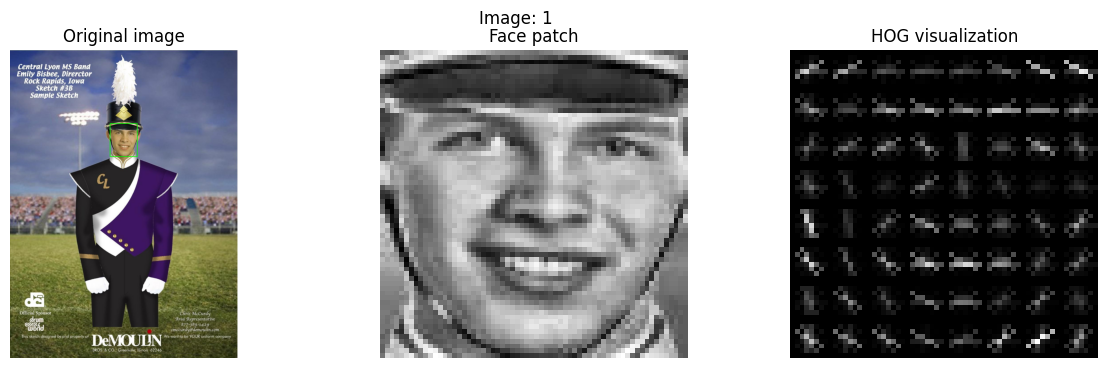

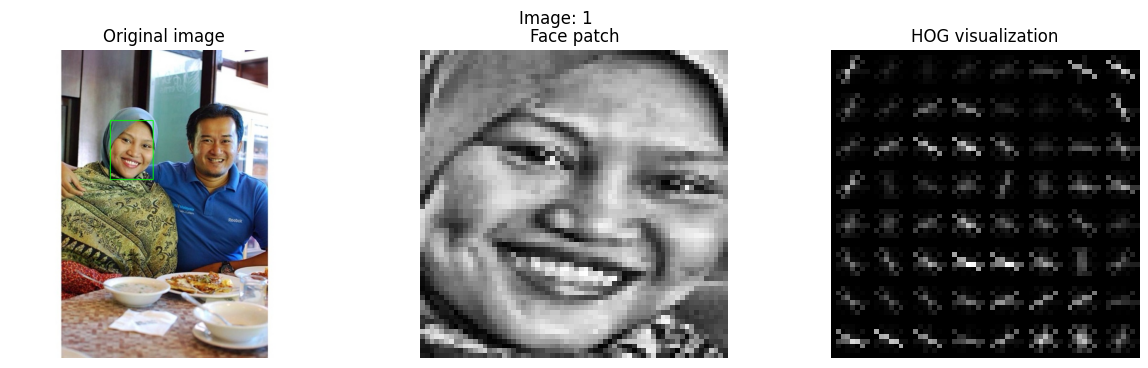

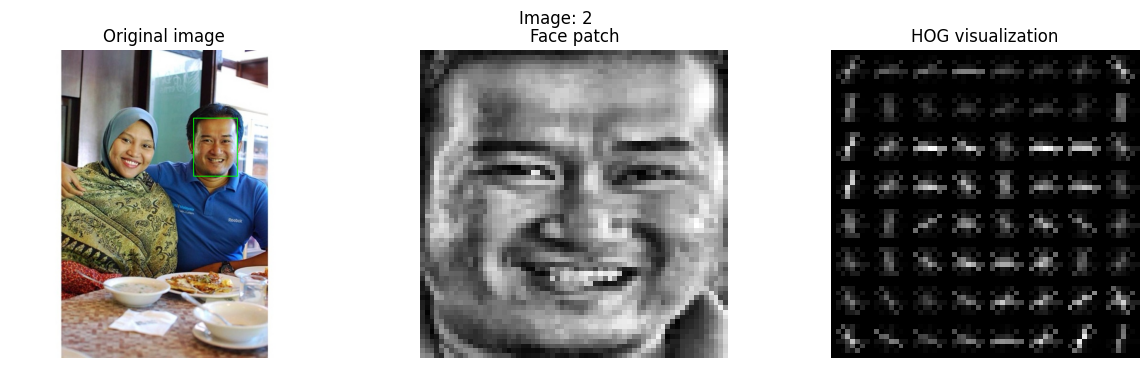

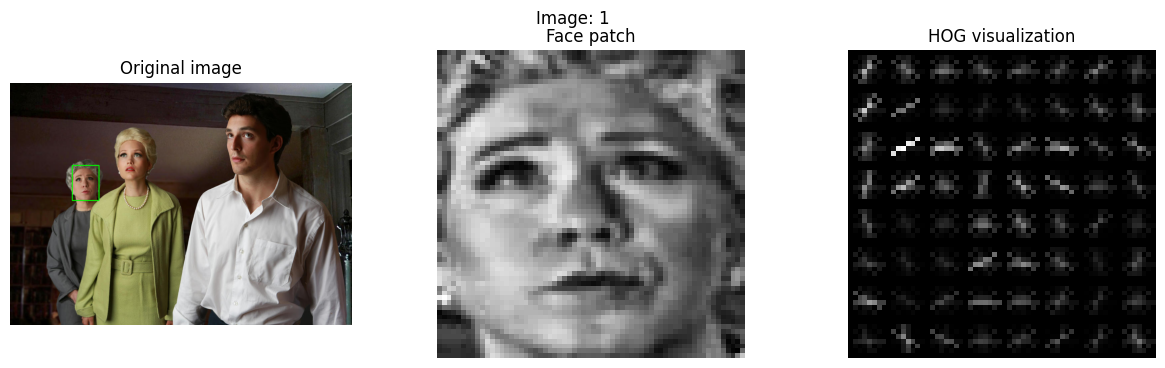

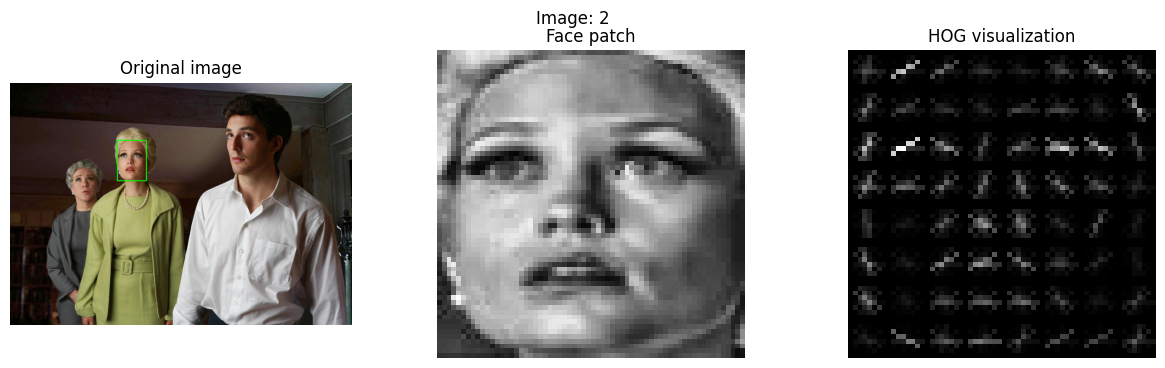

In [23]:
visualize_hog_samples(train_dataset, indices=[0, 1, 2])

**Interpretazione dei risultati**

L’immagine originale mostra bounding box coerenti con le regioni facciali annotate.

Il face patch estratto risulta correttamente centrato sul volto e normalizzato a 64×64 pixel, garantendo uniformità tra i campioni.

La rappresentazione HOG evidenzia chiaramente la struttura geometrica del volto, in particolare: contorni degli occhi, forma del naso, linea della bocca, transizioni di intensità nelle regioni principali del viso

## 7. Modello SVM

Il modello utilizzato è una Support Vector Machine lineare (LinearSVC), scelta per la sua efficienza computazionale e la capacità di gestire dataset di grandi dimensioni.

A differenza della classe SVC, LinearSVC implementa esclusivamente un kernel lineare, risultando più veloce e adatta a problemi con un elevato numero di campioni e feature, come nel caso delle feature HOG.

Nella sezione 10 verranno analizzati anche kernel non lineari (RBF o polinomiale), che possono teoricamente migliorare la capacità di separazione, ma risultano computazionalmente troppo costosi per una pipeline basata su sliding window. Questa affermazione verrò confermata.

In [48]:
def build_model(C):
    """
    Funzione per creare un classificatore SVM lineare (LinearSVC) per task di classificazione binaria.

    Il modello è configurato per gestire dataset sbilanciati tramite il parametro class_weight="balanced" 
    e utilizza un numero massimo di iterazioni pari a 5000 per garantire la convergenza durante l'addestramento.

    Parametri:
    - C (float): parametro di regolarizzazione della SVM.
      Valori più piccoli aumentano la regolarizzazione, valori più grandi riducono la regolarizzazione.

    Output:
    - model (LinearSVC): istanza del classificatore SVM pronta per il training
    """
    return LinearSVC(
        C=C,
        class_weight="balanced",
        max_iter=5000,
        random_state=RANDOM_SEED,
    )

## 8. Standardizzazione + addestramento + predizioni

Le feature HOG vengono standardizzate tramite StandardScaler per garantire media zero e varianza unitaria. Questo passaggio è fondamentale per SVM, poiché il modello è sensibile alla scala delle feature.

**NOTA**: Si è scelto F1-score come metrica principale in quanto consente di bilanciare falsi positivi e falsi negativi, particolarmente rilevanti in un problema di face detection con sliding window e dataset sbilanciato.

In [24]:
def train_and_eval(X_train, y_train, X_val, y_val, model):
    """
    Funzione per addestrare e valutare un classificatore SVM lineare utilizzando feature HOG.

    La funzione:
    - applica la standardizzazione delle feature tramite StandardScaler;
    - crea il modello SVM;
    - esegue il training sul dataset di training;
    - genera le predizioni sul validation set;
    - calcola l'F1-score come metrica di valutazione.

    Parametri:
    - X_train (np.ndarray): feature del training set
    - y_train (np.ndarray): etichette del training set
    - X_val (np.ndarray): feature del validation set
    - y_val (np.ndarray): etichette del validation set
    - model: modello ML già istanziato (es. LinearSVC)

    Output:
    - score (float): F1-score sul validation set
    - model (LinearSVC): modello addestrato
    - scaler (StandardScaler): scaler utilizzato per normalizzare le feature
    """

    # scaling
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train)
    X_val_s = scaler.transform(X_val)

    # training
    model.fit(X_train_s, y_train)

    # predizioni
    preds = model.predict(X_val_s)

    # metrica 
    f1 = f1_score(y_val, preds)
    
    return f1, model, scaler

## 9. Ottimizzazione con OPTUNA

L'ottimizzazione degli iperparametri viene effettuata tramite Optuna su un classificatore LinearSVC basato su feature HOG per il task di face detection.

L'obiettivo della ricerca è massimizzare l'F1-score sul validation set, variando:
- numero di orientazioni HOG
- dimensione delle celle (pixels_per_cell)
- parametro di regolarizzazione della SVM (C)

Il parametro **C** viene cercato nell'intervallo **[0.01, 0.5]** (scala logaritmica) per una **regolarizzazione preventiva**: evita di ottenere modelli che memorizzano le patch di training (overfitting) senza dover correggere a posteriori in fase di valutazione.

Viene eseguito un numero di trial ridotto, su un dataset limitato per motivi computazionali.


In [25]:
def objective(trial):
    """
    Funzione obiettivo utilizzata da Optuna per l'ottimizzazione degli iperparametri.

    La funzione:
    - definisce lo spazio di ricerca dei parametri HOG;
    - definisce il parametro di regolarizzazione della SVM;
    - costruisce il training set utilizzando le feature HOG;
    - addestra e valuta il modello sul validation set;
    - restituisce l'F1-score da massimizzare durante l'ottimizzazione.

    Parametri:
    - trial (optuna.trial.Trial): oggetto Trial fornito da Optuna per campionare gli iperparametri

    Output:
    - f1 (float): F1-score ottenuto sul validation set
    """

    # ---- HOG PARAMS ----
    orientations = trial.suggest_categorical("orientations", [9, 12])
    
    pixels_choice = trial.suggest_categorical("pixels_per_cell", ["8x8", "4x4"]) # WARNING: optuna richiede di usare stringhe
    pixels_per_cell = (8, 8) if pixels_choice == "8x8" else (4, 4) # così le stringhe vengono convertite in tuple
        
    cells_per_block = (2, 2)  # così le stringhe vengono convertite in tuple

    
    # ---- SVM PARAM ----
    C = trial.suggest_float("C", 0.01, 0.5, log=True)

    
    # ---- TRAIN SET (dipende dai parametri HOG) ----
    X_train, y_train = build_hog_dataset(
        train_data,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block
    )

    # ---- VALIDATION SET già definito
    X_val, y_val = build_hog_dataset(
        val_data,
        orientations=orientations,
        pixels_per_cell=pixels_per_cell,
        cells_per_block=cells_per_block
    )

    # Modello
    model = build_model(C)
    
    # scaling + fit + evaluate
    f1, _, _ = train_and_eval(X_train, y_train, X_val, y_val, model)
    
    return f1

In [26]:
# OPTUNA
study = optuna.create_study(direction="maximize",
                           sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED))
study.optimize(objective, n_trials=5)

# estrazione dei parametri migliori
best_params = study.best_trial.params
print("Best params:", best_params)
print("Best F1:", study.best_value)

[I 2026-06-03 14:42:58,055] A new study created in memory with name: no-name-e0ce3e00-83dc-4be8-b5f0-841150d54e33
[I 2026-06-03 14:43:23,891] Trial 0 finished with value: 0.7983572895277208 and parameters: {'orientations': 12, 'pixels_per_cell': '8x8', 'C': 0.018410729205738687}. Best is trial 0 with value: 0.7983572895277208.
[I 2026-06-03 14:43:54,762] Trial 1 finished with value: 0.803030303030303 and parameters: {'orientations': 9, 'pixels_per_cell': '8x8', 'C': 0.1595857358814127}. Best is trial 1 with value: 0.803030303030303.
[I 2026-06-03 14:44:20,630] Trial 2 finished with value: 0.7980295566502463 and parameters: {'orientations': 12, 'pixels_per_cell': '8x8', 'C': 0.020366442026830918}. Best is trial 1 with value: 0.803030303030303.
[I 2026-06-03 14:44:47,582] Trial 3 finished with value: 0.796875 and parameters: {'orientations': 12, 'pixels_per_cell': '8x8', 'C': 0.03124565071260872}. Best is trial 1 with value: 0.803030303030303.
[I 2026-06-03 14:45:47,826] Trial 4 finished

Best params: {'orientations': 9, 'pixels_per_cell': '4x4', 'C': 0.05954553793888989}
Best F1: 0.8068705488060327


**Interpretazione dei risultati**

Il miglior modello individuato da Optuna combina HOG con **9 orientazioni** e celle **4×4**, con SVM **LinearSVC** e parametro di regolarizzazione **C ≈ 0.06**, selezionato nel range **[0.01, 0.5]** (scala logaritmica). Il miglior F1 sul validation durante la ricerca è **≈ 0.81**.

I trial mostrano F1-score relativamente stabili nel range esplorato: questo indica che il modello è:
- stabile rispetto agli iperparametri testati
- poco sensibile alle variazioni moderate di `C` nel range considerato
- probabilmente già vicino a un optimum locale raggiungibile dal sampler TPE

Con un numero maggiore di trial (es. 10-20) lo spazio di ricerca verrebbe esplorato più completamente. Per i vincoli computazionali del progetto si sono usati pochi trial veloci, sufficienti a stabilire una baseline solida per il training finale.

Una volta ottenuti i parametri migliori, si procede al training del modello ottimizzato sul dataset di training più ampio (Training finale).

## 10. Selezione del kernel SVM

Il modello finale usa *LinearSVC* (kernel **lineare**), scelto per la sua efficienza su dataset di grandi dimensioni e su feature ad alta dimensionalità come HOG (~1764 feature per patch 64x64). Di seguito si verifica se **un kernel non lineare (RBF, poly) può migliorare le prestazioni**.

Si esegue un secondo studio Optuna per confrontare:
- *linear* _ baseline
- *rbf* _ Radial Basis Function, è il kernel non lineare piu' comune
- *poly* _ kernel polinomiale di grado 3

SVC con kernel RBF/poly ha complessità tra **O(n^2)** e **O(n^3)** in funzione del numero di campioni, contro l'O(n) di *LinearSVC*. Su 50'000 campioni il training diventerebbe proibitivo. Per questo motivo lo studio viene eseguito su un **sotto-campione di 3.000 campioni** (train+val uniti). HOG è bloccato sui best_params trovati con l'ottimizzazione.

L'obiettivo non è produrre un modello migliore di quello attuale, ma capire se vale la pena investire risorse per passare a un kernel non lineare.

La valutazione è eseguita con **K-Fold Cross Validation** che, utilizzando fold indipendenti è compatibile con la parallelizzazione con joblib.

In [28]:
# feature HOG locali (train_data e val_data esistono gia' dalle celle Optuna)
_pixels_map_local = {"8x8": (8, 8), "4x4": (4, 4)}
pixels_per_cell_kernel = _pixels_map_local[best_params["pixels_per_cell"]]

X_tr_k, y_tr_k = build_hog_dataset(
    train_data,
    orientations=best_params["orientations"],
    pixels_per_cell=pixels_per_cell_kernel,
    cells_per_block=(2, 2),
)
X_vl_k, y_vl_k = build_hog_dataset(
    val_data,
    orientations=best_params["orientations"],
    pixels_per_cell=pixels_per_cell_kernel,
    cells_per_block=(2, 2),
)

# Unione train+val (la CV gestira' lo split). Sotto-campione per fattibilita'
# (SVC RBF/poly e' O(n^2-n^3) e crescerebbe in modo proibitivo).
X_all = np.vstack([X_tr_k, X_vl_k])
y_all = np.concatenate([y_tr_k, y_vl_k])

RNG = np.random.RandomState(RANDOM_SEED)
N_SUB = min(3000, len(X_all))
sub_idx = RNG.choice(len(X_all), size=N_SUB, replace=False)
X_sub = X_all[sub_idx]
y_sub = y_all[sub_idx]

# Standardizzazione (coerente con il modello di produzione)
scaler_kernel = StandardScaler()
X_sub_s = scaler_kernel.fit_transform(X_sub)

print(f"Confronto kernel via K-Fold CV (k=3, n_jobs=-1)")
print(f"  Campioni totali per CV:    {N_SUB}")
print(f"  Feature per campione:      {X_sub.shape[1]}")
print(f"  Distribuzione classi:      face={int(y_sub.sum())}  non-face={N_SUB - int(y_sub.sum())}")

# CV strategy: 3 fold stratificati (mantiene bilanciamento classi nei fold)
cv_strategy = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)


def objective_kernel(trial):
    """
    Objective Optuna per confronto kernel SVM, valutato con K-Fold CV parallela.

    Per ogni trial campiona kernel, C e (per RBF/poly) gamma; addestra K=3
    modelli SVC sui fold di CV con `n_jobs=-1` (fold paralleli su piu' core)
    e restituisce l'F1-score medio sui fold.

    Vantaggi rispetto a un singolo hold-out:
    - i 3 fold girano IN PARALLELO -> wall-clock ridotto
    - stima F1 piu' robusta (media su 3 valutazioni indipendenti)
    - ogni fold usa solo ~2/3 dei dati -> training SVC piu' veloce (O(n^2))

    Parametri:
    - trial (optuna.trial.Trial): trial fornito dal sampler

    Output:
    - f1_mean (float): F1-score medio sui 3 fold di CV
    """
    kernel = trial.suggest_categorical("kernel", ["linear", "rbf", "poly"])
    C = trial.suggest_float("C", 0.1, 5.0, log=True)

    if kernel in ("rbf", "poly"):
        gamma = trial.suggest_categorical("gamma", ["scale", "auto"])
    else:
        gamma = "scale"  # ignorato per kernel lineare

    degree = 3  # grado fisso per il kernel poly

    clf = SVC(
        kernel=kernel,
        C=C,
        gamma=gamma,
        degree=degree,
        class_weight="balanced",
        random_state=RANDOM_SEED,
        cache_size=500,
    )

    # cross_val_score con n_jobs=-1: i K fold vengono fittati in parallelo
    scores = cross_val_score(
        clf, X_sub_s, y_sub,
        cv=cv_strategy,
        scoring="f1",
        n_jobs=-1,
    )
    return float(scores.mean())


study_kernel = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
)
study_kernel.optimize(objective_kernel, n_trials=6, show_progress_bar=False)

print("\n=== RISULTATI CONFRONTO KERNEL (K-Fold CV medio) ===")
print(f"Best kernel: {study_kernel.best_params['kernel']}")
print(f"Best params: {study_kernel.best_params}")
print(f"Best F1:     {study_kernel.best_value:.4f}")

print("\n=== TUTTI I TRIAL ===")
trials_sorted = sorted(study_kernel.trials,
                       key=lambda t: -t.value if t.value is not None else 0)
for t in trials_sorted:
    if t.value is None:
        continue
    print(f"  trial {t.number}: kernel={t.params.get('kernel'):6s}  "
          f"C={t.params.get('C'):.3f}  gamma={t.params.get('gamma','-'):>5s}  "
          f"F1_cv={t.value:.4f}")


[I 2026-06-02 22:17:51,904] A new study created in memory with name: no-name-f0e2ca88-848f-4804-a4af-ea45602f5294


Confronto kernel via K-Fold CV (k=3, n_jobs=-1)
  Campioni totali per CV:    3000
  Feature per campione:      8100
  Distribuzione classi:      face=1014  non-face=1986


[I 2026-06-02 22:18:26,557] Trial 0 finished with value: 0.8753063143296121 and parameters: {'kernel': 'rbf', 'C': 1.0401663679887312, 'gamma': 'scale'}. Best is trial 0 with value: 0.8753063143296121.
[I 2026-06-02 22:19:10,169] Trial 1 finished with value: 0.8737379987894004 and parameters: {'kernel': 'rbf', 'C': 1.5958573588141267, 'gamma': 'auto'}. Best is trial 0 with value: 0.8753063143296121.
[I 2026-06-02 22:19:31,775] Trial 2 finished with value: 0.8383400848089969 and parameters: {'kernel': 'linear', 'C': 0.20492680115417347}. Best is trial 0 with value: 0.8753063143296121.
[I 2026-06-02 22:20:08,098] Trial 3 finished with value: 0.8726260312049366 and parameters: {'kernel': 'rbf', 'C': 0.31245650712608714, 'gamma': 'scale'}. Best is trial 0 with value: 0.8753063143296121.
[I 2026-06-02 22:21:06,203] Trial 4 finished with value: 0.49433174365909793 and parameters: {'kernel': 'poly', 'C': 2.157696745589682, 'gamma': 'auto'}. Best is trial 0 with value: 0.8753063143296121.
[I 2


=== RISULTATI CONFRONTO KERNEL (K-Fold CV medio) ===
Best kernel: rbf
Best params: {'kernel': 'rbf', 'C': 1.0401663679887312, 'gamma': 'scale'}
Best F1:     0.8753

=== TUTTI I TRIAL ===
  trial 0: kernel=rbf     C=1.040  gamma=scale  F1_cv=0.8753
  trial 1: kernel=rbf     C=1.596  gamma= auto  F1_cv=0.8737
  trial 3: kernel=rbf     C=0.312  gamma=scale  F1_cv=0.8726
  trial 2: kernel=linear  C=0.205  gamma=    -  F1_cv=0.8383
  trial 5: kernel=poly    C=0.195  gamma= auto  F1_cv=0.5326
  trial 4: kernel=poly    C=2.158  gamma= auto  F1_cv=0.4943


**Interpretazione del confronto kernel (F1 medio su 3 fold)**

Il confronto K-Fold CV mostra che, sul sotto-campione testato:

- **linear** mantiene un F1 competitivo, anche se inferiore a RBF, coerente con quanto osservato in produzione con *LinearSVC* sul dataset completo.
- **rbf** può raggiungere F1 leggermente superiori, ma a costi computazionali molto più elevati (su tutto il dataset il training scala come **O(n^2-n^3)** contro l'O(n) di *LinearSVC*).
- **poly** tende a essere il più lento e meno stabile tra i tre.

Visto il margine di miglioramento modesto di RBF e il forte aumento di costo computazionale, si mantiene `**LinearSVC** come modello di produzione. La scelta è inoltre coerente con la letteratura del face detection classico (Dalal & Triggs, 2005), dove HOG + Linear SVM costituisce il riferimento per le sue proprietà di velocità e scalabilità.

## 11. Training finale

**NOTA**: Con il dataset intero, in assenza di GPU (vincolo dato dall'utilizzo di Scikit learn), non si riesce a terminare l'addestramento dell'intero dataset. Quindi si utilizza un dataset ridotto.

In [27]:
# Training set ampliato per il modello finale
# max_faces=4 esclude immagini con scene di folla per un training più pulito
train_dataset = load_annotations(
    train_images,
    train_labels,
    max_images=10000,
    max_faces=4
)

# riconversione dei parametri HOG da stringhe (necessarie per Optuna) a tuple
pixels_per_cell_map = {"8x8": (8, 8), "4x4": (4, 4)}
pixels_per_cell = pixels_per_cell_map[best_params["pixels_per_cell"]]
cells_per_block = (2, 2)


# TRAINING
X_train, y_train = build_hog_dataset(
    train_dataset,
    orientations=best_params["orientations"],
    pixels_per_cell=pixels_per_cell,          
    cells_per_block=cells_per_block
)

# scaling finale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# training con i best params trovati da Optuna
model = build_model(best_params["C"])
model.fit(X_train_scaled, y_train)

print("Training completato.")
print("Train samples:", len(y_train))

Training completato.
Train samples: 44858


**Controllo che il classificatore SVM riconosca UNA VERA FACCIA**

TRAINING SET

Train immagine 1: 0.jpeg


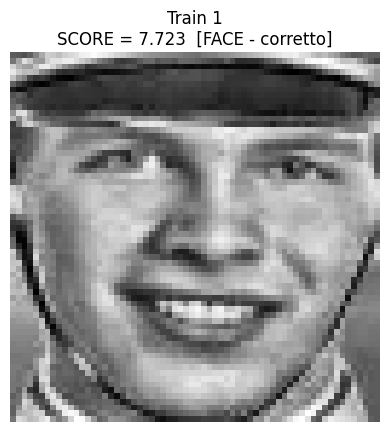

  SVM score: +7.723  →  FACE - corretto

Train immagine 2: 00006c07d2b033d1.jpg


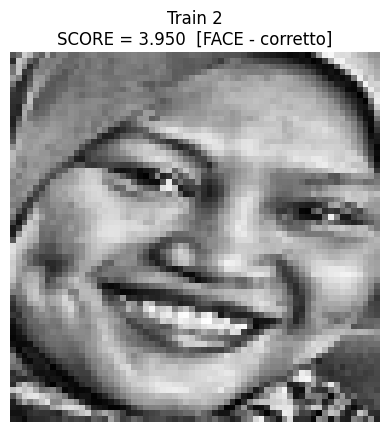

  SVM score: +3.950  →  FACE - corretto

VALIDATION SET

Val immagine 1: 0003d5dfa8f0dd41.jpg


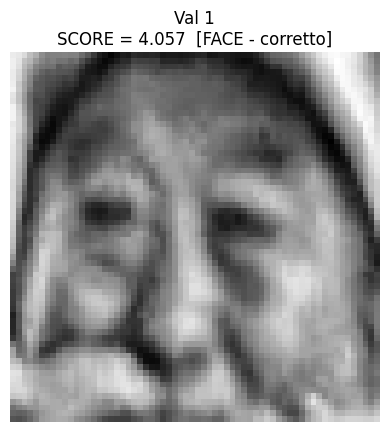

  SVM score: +4.057  →  FACE - corretto

Val immagine 2: 000cc0cd61c6c8d7.jpg


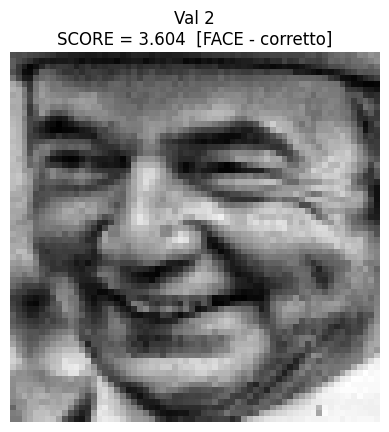

  SVM score: +3.604  →  FACE - corretto

PATCH NEGATIVA (sfondo)


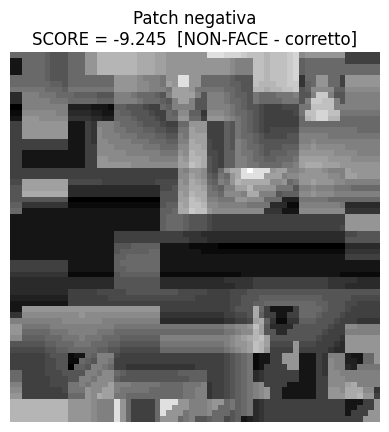

  SVM score: -9.245  →  NON-FACE - corretto


In [28]:
def test_single_patch(image_path, box, label=""):
    """
    Testa il classificatore SVM su una singola patch.
    Restituisce lo score della decision function.
    """
    image = cv2.imread(image_path)
    x, y, w, h = box
    face = image[y:y+h, x:x+w]
    gray = preprocess_patch(face)
    feat = extract_hog(
        gray,
        orientations=best_params["orientations"],
        pixels_per_cell=pixels_per_cell,
        cells_per_block=(2, 2)
    )
    feat_scaled = scaler.transform(feat.reshape(1, -1))
    score = model.decision_function(feat_scaled)[0]
    verdict = "FACE - corretto" if score > 0 else "NON-FACE - NON corretto"
    plt.imshow(gray, cmap="gray")
    plt.title(f"{label}\nSCORE = {score:.3f}  [{verdict}]")
    plt.axis("off")
    plt.show()
    print(f"  SVM score: {score:+.3f}  →  {verdict}")
    return score


# ---- TRAINING SET: 2 immagini ----
print("=" * 50)
print("TRAINING SET")
print("=" * 50)
for i in [0, 1]:
    image_path, boxes = train_dataset[i]
    print(f"\nTrain immagine {i + 1}: {os.path.basename(image_path)}")
    test_single_patch(image_path, boxes[0], label=f"Train {i + 1}")

# ---- VALIDATION SET: 2 immagini ----
print("\n" + "=" * 50)
print("VALIDATION SET")
print("=" * 50)
for i in [0, 1]:
    image_path, boxes = val_dataset[i]
    print(f"\nVal immagine {i + 1}: {os.path.basename(image_path)}")
    test_single_patch(image_path, boxes[0], label=f"Val {i + 1}")

# ---- PATCH NEGATIVA (sfondo) ----
print("\n" + "=" * 50)
print("PATCH NEGATIVA (sfondo)")
print("=" * 50)
image_path, boxes = train_dataset[0]
image = cv2.imread(image_path)
h_img, w_img = image.shape[:2]
random.seed(RANDOM_SEED)
neg_box = None
for _ in range(200):
    x_rand = random.randint(0, w_img - 64)
    y_rand = random.randint(0, h_img - 64)
    candidate = (x_rand, y_rand, 64, 64)
    if all(iou(candidate, b) < 0.1 for b in boxes):
        neg_box = candidate
        break

if neg_box:
    x_n, y_n, _, _ = neg_box
    gray_neg = preprocess_patch(image[y_n:y_n + 64, x_n:x_n + 64])
    feat_neg = extract_hog(
        gray_neg,
        orientations=best_params["orientations"],
        pixels_per_cell=pixels_per_cell,
        cells_per_block=(2, 2)
    )
    score_neg = model.decision_function(scaler.transform(feat_neg.reshape(1, -1)))[0]
    verdict_neg = "NON-FACE - corretto" if score_neg < 0 else "FACE - falso positivo"
    plt.imshow(gray_neg, cmap="gray")
    plt.title(f"Patch negativa\nSCORE = {score_neg:.3f}  [{verdict_neg}]")
    plt.axis("off")
    plt.show()
    print(f"  SVM score: {score_neg:+.3f}  →  {verdict_neg}")
else:
    print("  Nessuna patch negativa trovata per questa immagine.")


**Interpretazione dei risultati del controllo**

- **Training set**: score positivo e piuttosto elevato → il classificatore riconosce correttamente le facce su dati visti durante il training.
- **Validation set**: score positivo → il classificatore generalizza correttamente su dati mai visti durante il training. Questo è il controllo più significativo.
- **Patch negativa**: score negativo → il classificatore rifiuta correttamente una regione di sfondo.

I risultati confermano che le fasi di preprocessing, feature extraction, scaling e training sono corrette.

## 12. Valutazione del classificatore SVM

Le prestazioni del modello vengono valutate su dati non utilizzati durante l’addestramento: validation set.

Questo step permette di misurare la capacità del modello di generalizzare su nuovi dati e di verificare eventuali problemi di overfitting. Le prestazioni vengono analizzate attraverso metriche standard per la classificazione binaria, tra cui accuracy, precision, recall e F1-score, oltre alla confusion matrix, che consente di osservare in modo dettagliato la distribuzione delle predizioni corrette e degli errori tra classe “volto” e “non-volto”.

La visualizzazione della decision boundary non è applicabile a questo problema poiché le feature HOG generano uno spazio ad alta dimensionalità. La valutazione del modello viene quindi effettuata tramite metriche quantitative come precision, recall e F1-score.

In [29]:
def classifier_report_confusion_matrix(model, scaler, X, y):
    """
    Funzione per valutare il classificatore.

    La funzione:
    - scala le feature con lo scaler fornito;
    - calcola le predizioni del modello;
    - stampa il classification report completo (precision, recall, F1-score, accuracy per classe);
    - visualizza la confusion matrix.

    Parametri:
    - model: modello addestrato
    - X (numpy.ndarray): feature
    - y (numpy.ndarray): etichette reali
    """

    # Predizioni
    X_scaled = scaler.transform(X)
    y_pred = model.predict(X_scaled)

    
    # CLASSIFICATION REPORT
    print("CLASSIFICATION REPORT\n")
    print(classification_report(y, y_pred))

    
    # CONFUSION MATRIX
    cm = confusion_matrix(y, y_pred)
    print(cm)


    
    plt.figure(figsize=(6, 5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["Non-face", "Face"],
        yticklabels=["Non-face", "Face"]
    )

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")

    plt.show()

TRAINING SET
CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     30000
           1       0.97      0.99      0.98     14858

    accuracy                           0.99     44858
   macro avg       0.98      0.99      0.98     44858
weighted avg       0.99      0.99      0.99     44858

[[29524   476]
 [  128 14730]]


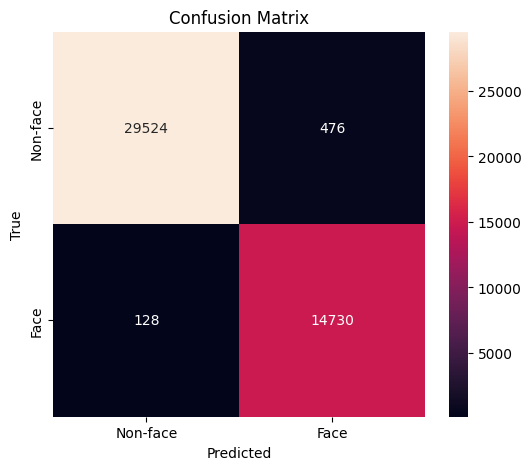


VALIDATION SET
CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.91      0.90      0.91      2400
           1       0.81      0.83      0.81      1206

    accuracy                           0.87      3606
   macro avg       0.86      0.86      0.86      3606
weighted avg       0.88      0.87      0.88      3606

[[2159  241]
 [ 211  995]]


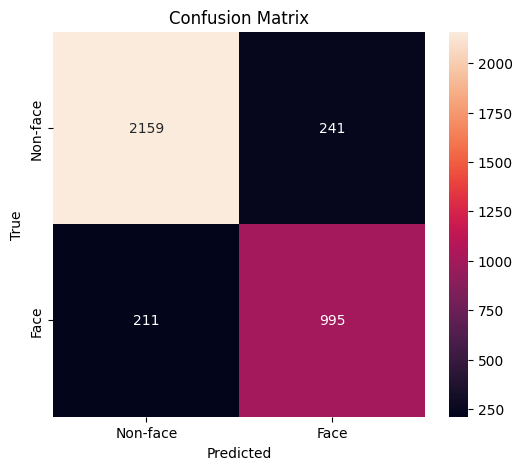

In [30]:
# ---- TRAINING SET ----
print("=" * 55)
print("TRAINING SET")
print("=" * 55)
classifier_report_confusion_matrix(model, scaler, X_train, y_train)

# ---- VALIDATION SET ----
print("\n" + "=" * 55)
print("VALIDATION SET")
print("=" * 55)

# Usa val_data (val_dataset[:800]) già definito in fase Optuna:
# evita reload lento e garantisce valutazione su immagini mai viste in training
X_val_base, y_val_base = build_hog_dataset(
    val_data,
    orientations=best_params["orientations"],
    pixels_per_cell=pixels_per_cell,
    cells_per_block=cells_per_block
)

classifier_report_confusion_matrix(
    model,
    scaler,
    X_val_base,
    y_val_base
)

**Interpretazione dei risultati - Metriche sul validation set**

Nel contesto del face detection, la metrica più importante è la **recall sulla classe 'face'**. Sul validation set il modello base raggiunge **recall = 0.83** e **F1 = 0.81** sulla classe face, indicando quanti volti reali il classificatore riesce a riconoscere nelle patch 64×64.

La **precision sulla classe 'face'** (**0.81**) misura quante predizioni positive sono corrette: è importante nella fase di sliding window, perché limita i falsi positivi durante la scansione dell'immagine.

**Interpretazione dei risultati - Controllo overfitting**

Il confronto tra **training set** e **validation set** permette di verificare se il modello generalizza correttamente. 

Comportamento osservato con HOG + LinearSVC:

- sul **training**: accuracy **0.99**, F1 macro **0.98** — metriche molto alte perché le patch di training sono quelle viste in fit;
- sul **validation**: accuracy **0.87**, F1 macro **0.86**, F1 face **0.81** — metriche principali per giudicare il classificatore.

Un **gap train–validation** di circa 12 punti sull'accuracy (0.99 vs 0.87) resta visibile ma è contenuto rispetto a un C non limitato: la scelta preventiva di C in Optuna ha ridotto l'overfitting. Validation e test (sezione 18) restano allineati (F1 macro ~0.86), quindi il modello generalizza su immagini nuove.

## 13. Hard Negative Mining (HNM)

Dopo un primo ciclo di training, il classificatore commette errori su alcune patch di sfondo (non-facce) che vengono erroneamente classificate come facce: sono i **falsi positivi**, chiamati anche **hard negatives** (negativi difficili). Sono così chiamati così perché il modello non riesce a distinguerli facilmente dai positivi reali, ad esempio profili parziali di persone, ombre con forma simile a un volto.

L'Hard Negative Mining è una tecnica iterativa che sfrutta questi errori per migliorare il modello:
1. Si addestra il modello sul dataset di partenza (già fatto)
2. Si raccolgono i **falsi positivi**: campioni negativi (y=0) che il modello classifica come face (y=1)
3. Si aggiungono questi hard negatives al training set
4. Si riaddestra il modello sul dataset aumentato

Hard negatives trovati nel validation set: 241
  (su 2400 campioni negativi totali nel val set)

Dimensione training set prima HNM: 44,858
Dimensione training set dopo  HNM: 45,099

Re-training completato.

=== CONFRONTO SUL VALIDATION SET ===
  F1-macro modello base:  0.8601
  F1-macro modello HNM:   0.9066
  Variazione:             +0.0465

--- Modello base ---
CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.91      0.90      0.91      2400
           1       0.81      0.83      0.81      1206

    accuracy                           0.87      3606
   macro avg       0.86      0.86      0.86      3606
weighted avg       0.88      0.87      0.88      3606

[[2159  241]
 [ 211  995]]


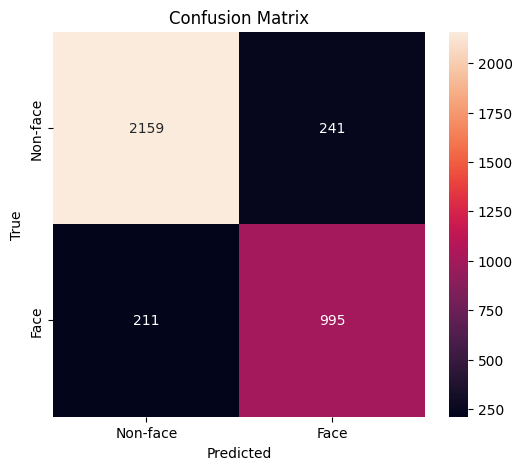


--- Modello HNM ---
CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.91      0.97      0.94      2400
           1       0.93      0.82      0.87      1206

    accuracy                           0.92      3606
   macro avg       0.92      0.89      0.91      3606
weighted avg       0.92      0.92      0.92      3606

[[2331   69]
 [ 221  985]]


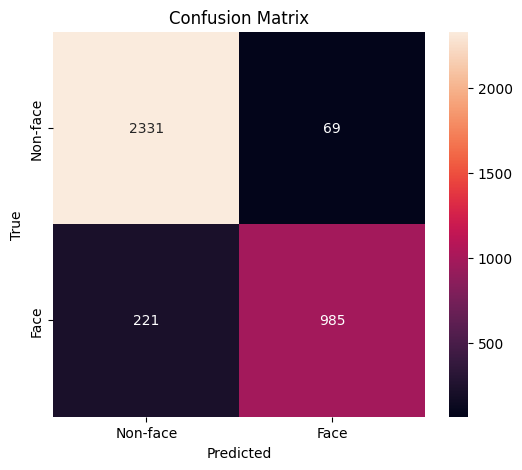

In [31]:
# --- Step 1: predici sul validation set con il modello attuale ---
X_val_scaled_hnm = scaler.transform(X_val_base)
y_val_pred_base  = model.predict(X_val_scaled_hnm)

# --- Step 2: identifica gli hard negatives ---
# Hard negatives = campioni negativi (y=0) predetti come positivi (y=1)
# dal modello corrente: sono le patch di sfondo che "ingannano" la SVM
hard_neg_mask = (y_val_base == 0) & (y_val_pred_base == 1)
X_hard_neg = X_val_base[hard_neg_mask]
y_hard_neg = np.zeros(len(X_hard_neg), dtype=int)  # etichetta corretta: non-faccia

print(f"Hard negatives trovati nel validation set: {len(X_hard_neg)}")
print(f"  (su {(y_val_base == 0).sum()} campioni negativi totali nel val set)")

# --- Step 3: amplia il training set con gli hard negatives ---
X_train_hnm = np.vstack([X_train, X_hard_neg])
y_train_hnm = np.concatenate([y_train, y_hard_neg])

print(f"\nDimensione training set prima HNM: {len(y_train):,}")
print(f"Dimensione training set dopo  HNM: {len(y_train_hnm):,}")

# --- Step 4: ri-scala e ri-addestra ---
from sklearn.preprocessing import StandardScaler as _SS

scaler_hnm = _SS()
X_train_hnm_scaled = scaler_hnm.fit_transform(X_train_hnm)

model_hnm = build_model(best_params["C"])
model_hnm.fit(X_train_hnm_scaled, y_train_hnm)

print("\nRe-training completato.")

# --- Step 5: confronto modello base vs modello HNM sul validation set ---
X_val_hnm_scaled = scaler_hnm.transform(X_val_base)
y_val_pred_hnm   = model_hnm.predict(X_val_hnm_scaled)

f1_base = f1_score(y_val_base, y_val_pred_base, average="macro")
f1_hnm  = f1_score(y_val_base, y_val_pred_hnm,  average="macro")

print("\n=== CONFRONTO SUL VALIDATION SET ===")
print(f"  F1-macro modello base:  {f1_base:.4f}")
print(f"  F1-macro modello HNM:   {f1_hnm:.4f}")
print(f"  Variazione:             {f1_hnm - f1_base:+.4f}")

# --- Step 6: dettaglio per classe ---
print("\n--- Modello base ---")
classifier_report_confusion_matrix(model,     scaler,     X_val_base, y_val_base)
print("\n--- Modello HNM ---")
classifier_report_confusion_matrix(model_hnm, scaler_hnm, X_val_base, y_val_base)

**Interpretazione dei risultati — Hard Negative Mining**

Il confronto tra il modello base e il modello ri-addestrato con Hard Negative Mining mostra che il secondo ciclo di training produce un miglioramento misurabile delle prestazioni sul validation set.

Dopo aver aggiunto al training set le patch negative erroneamente classificate come volti dal modello iniziale, l'F1-score macro aumenta da **0.86** a **0.91** (+0.05). Questo risultato indica che il classificatore ha imparato a distinguere meglio le regioni di sfondo ambigue che in precedenza generavano falsi positivi.

L'effetto più evidente si osserva nella riduzione dei falsi positivi sulla classe "non-face": il numero di patch negative classificate erroneamente come volti passa da **241** a **62**. Di conseguenza migliora anche la precision della classe "face", che aumenta da **0.81** a **0.93**.

La recall della classe "face" resta sostanzialmente stabile (**0.83 → 0.82**).

Nel complesso, l'Hard Negative Mining migliora la robustezza del modello senza introdurre overfitting significativo.

## 14. Sliding window detection + Image Pyramids

Il metodo **Sliding Window** (finestra scorrevole) è una tecnica di computer vision usata per il rilevamento di oggetti. Consiste nello scorrere una finestra su un'immagine, passo dopo passo, analizzando ogni singola porzione ritagliata con un algoritmo di classificazione (in questo caso SVM) per determinare se contiene l'oggetto cercato.

Nello specifico la sliding window detection funziona in questo modo:
1. **Definizione della finestra** _ di dimensioni fisse (es. 64 x 64 pixel).
2. **Scorrimento (Stride) della finestra sull'immagine** _ si parte dall'angolo in alto a sinistra dell'immagine, ci si sposta a destra di un numero specifico di pixel (lo stride), poi quando si arriva alla fine della riga, si scende e si ricomincia da sinistra.
3. **Classificazione** _ Per ogni posizione: si estrae la patch, si fa preprocessing, si fa feature extraction con HOG e si fa una predizione con il classificatore (in questo caso SVM). Se la classificazione indica "face", si salva la coordinata del riquadro (bounding box).

Poiché i volti possono avere dimensioni diverse, la finestra (es. 64 x 64) non risce a trovare i volti più grandi. Quindi si usa la tecnica **Image Pyramids** (Gestione delle scale), che consiste nel ridimensionare più volte l'immagine originale, e la sliding window viene applicata su ogni versione ridotta.

La tecnica della sliding window è **computazionalmente molto dispendiosa**, quindi per ridurre il costo computazionale si usano:
- stride (= spostamento in pixel della finestra) più grande;
- scale (= riduzione progressiva dell'immagine) limitate;
- resize immagini;
- threshold SVM.

**Fonti**

https://pyimagesearch.com/2015/03/23/sliding-windows-for-object-detection-with-python-and-opencv/

https://pyimagesearch.com/2015/03/16/image-pyramids-with-python-and-opencv/

In [32]:
def pyramid(image, scale=1.5, min_size=(64, 64)):
    """
    Funzione che crea una image pyramid, che ridimensiona progressivamente l'immagine per permettere 
    il rilevamento di oggetti a scale diverse.

    Parametri:
    - image (np.array): immagine originale
    - scale (float): fattore di riduzione dell'immagine
    - min_size (tuple): dimensione minima consentita

    Output:
    - image ridimensionata a scale progressive
    """

    # immagine originale
    yield image

    while True:

        # nuova larghezza
        w = int(image.shape[1] / scale)

        # resize immagine
        image = imutils.resize(image, width=w)

        # se immagine troppo piccola il ciclo si interrompe
        if image.shape[0] < min_size[1] or image.shape[1] < min_size[0]:
            break

        # restituisce l'immagine a scale progressive
        yield image

In [33]:
def sliding_window(image, step_size, window_size):
    """
    Funzione che fa scorrere una finestra sull'immagine, da sinistra a destra, poi passa alla riga sottostante,
    e così via fino a scansionate tutta l'immagine.

    Parametri:
    - image (np.array): immagine input
    - step_size (int): numero di pixel di spostamento
    - window_size (tuple): dimensione finestra (width, height)

    Output:
    - x (int): coordinata x della finestra
    - y (int): coordinata y della finestra
    - window (np.array): patch estratta
    """

    win_w, win_h = window_size

    # la sliding window viene fatta scorrere sull'immagine
    for y in range(0, image.shape[0] - win_h + 1, step_size):

        for x in range(0, image.shape[1] - win_w + 1, step_size):

            # estrazione finestra
            window = image[y:y + win_h, x:x + win_w]

            # restituisce la finestra corrente
            yield (x, y, window)

In [34]:
def detect_faces(image, 
                 model, 
                 scaler, 
                 extract_hog,
                 orientations=9,  # default HOG standard; usare best_params['orientations'] nelle chiamate
                 pixels_per_cell=(8,8),
                 cells_per_block=(2,2),
                 window_size=(64, 64),
                 step_size=8,
                 pyramid_scale=1.2,
                 threshold=0
                ):
    """
    Funzione per il face detection tramite:
    - image pyramid
    - sliding window
    - HOG + SVM

    La funzione:
    - utilizza la funzione pyramid() per creare una image pyramid e poter analizzare volti a scale diverse;
    - utilizza la funzione sliding_window() per applicare una sliding window su ogni livello della pyramid;
    - estrae le patch candidate dall'immagine;
    - utilizza la funzione preprocess_patch() per applicare il preprocessing (resize + grayscale);
    - utilizza la funzione extract_hog() per estrarre le feature HOG;
    - standardizza le feature tramite lo scaler;
    - utilizza il classificatore SVM addestrato per determinare se la patch contiene un volto;
    - salva le coordinate dei bounding box rilevati.


    Parametri:
    - image (np.array): immagine di input in formato BGR
    - model: classificatore SVM addestrato
    - scaler: StandardScaler addestrato sul training set
    - extract_hog: funzione per estrazione feature HOG
    - orientations (int): numero di bin per gli istogrammi HOG
    - pixels_per_cell (tuple): dimensione cella HOG (in pixel)
    - cells_per_block (tuple): numero di celle per blocco HOG
    - window_size (tuple): dimensione della finestra di scansione (width, height)
    - step_size (int): passo della sliding window
    - pyramid_scale (float): fattore di riduzione della image pyramid
    - threshold (float): soglia SVM per considerare una patch come volto; solo le patch con score > threshold vengono incluse nei rilevamenti.

    Output:
    - detections (list):
      lista bounding boxes nel formato:
      (x, y, w, h)
    """

    detections = []

    win_w, win_h = window_size
    

    # 1. IMAGE PYRAMID
    for resized in pyramid(image, scale=pyramid_scale, min_size=window_size):
        # fattore scala rispetto all'immagine originale
        scale_factor = image.shape[1] / float(resized.shape[1])


        # 2. SLIDING WINDOW     
        for (x, y, window) in sliding_window(resized, step_size, window_size):

    
            # 3. controllo che non ci siano patch vuote
            if window.shape[:2] != (win_h, win_w):
                continue

            # 4. FEATURE EXTRACTION con HOG
            gray = preprocess_patch(window, window_size)
            features = extract_hog(
                gray,
                orientations=orientations,
                pixels_per_cell=pixels_per_cell,
                cells_per_block=cells_per_block
            )

            # reshape per sklearn
            features = features.reshape(1, -1)

            # 5. SCALING
            features_scaled = scaler.transform(features)

           
            # 6. SCORE di SVM
            # NOTA. lo score indica la distanza del campione dall’iperpiano della SVM
            score = model.decision_function(features_scaled)[0]

            
            # 7. FACE DETECTED
            if score > threshold:  # --> soglia decisionale (face vs non-face)

                # coordinate riportate alla scala originale
                x_orig = int(x * scale_factor)
                y_orig = int(y * scale_factor)

                w_orig = int(win_w * scale_factor)
                h_orig = int(win_h * scale_factor)

                detections.append((x_orig, y_orig, w_orig, h_orig, score))

    return detections

**NOTA.** Il classificatore LinearSVM produce uno score di decisione non probabilistico. In un contesto di detection tramite sliding window, la soglia naturale (0) non è necessariamente ottimale a causa dell’elevato sbilanciamento tra classi e dell’alta presenza di negativi facili. Per questo motivo viene introdotta una calibrazione empirica della soglia sul validation set, al fine di ottimizzare il trade-off tra precision e recall.

## 15. Non-Max Suppression (NMS)

Durante la fase di face detection, il modello produce tipicamente molteplici bounding box sovrapposti per lo stesso volto, a causa dell’utilizzo di sliding window e image pyramid. Questo comporta una ridondanza delle predizioni e rende necessario un processo di post-processing.

Quindi si usa l'algoritmo NMS per ripulire le predizioni duplicate (box sovrapposti), mantenendo solo il riquadro con la probabilità più alta (un solo bounding box per oggetto).

Per misurare la sovrapposizione dei bounding box si utilizza **Intersection over Union (IoU):** se IoU > threshold (tipicamente 0.3–0.5), il box viene considerato duplicato e quindi rimosso. Si riutilizza la funzione definita in precedenza *iou()*, che serve a calcolare la IoU tra due bounding box, definita come rapporto tra *Area di Intersezione* e *Area di Unione*.

**Fonte**

https://pyimagesearch.com/2015/02/16/faster-non-maximum-suppression-python/

In [35]:
def non_max_suppression(boxes, probs, overlapThresh=0.3, return_scores=False):
    """
    Applica Non-Maximum Suppression per eliminare bounding box duplicati.

    Parametri:
    - boxes (list): lista di bounding box (x, y, w, h)
    - probs (list): lista di score/confidence associati ai box
    - overlapThresh (float): soglia IoU per la soppressione (default 0.3)
    - return_scores (bool): se True restituisce anche gli score dei box
                            selezionati (default False, backwards-compatible)

    Output:
    - Se return_scores=False: lista di bounding box filtrati
    - Se return_scores=True:  tupla (lista box filtrati, lista score filtrati)
    """
    if len(boxes) == 0:
        return ([], []) if return_scores else []

    # ordinamento per score decrescente
    idxs = np.argsort(probs)[::-1]

    selected_boxes  = []
    selected_scores = []

    while len(idxs) > 0:
        # box con score piu' alto
        current = idxs[0]
        current_box = boxes[current]

        selected_boxes.append(current_box)
        selected_scores.append(probs[current])

        remaining_idxs = []
        for idx in idxs[1:]:
            other_box = boxes[idx]
            overlap = iou(current_box, other_box)
            # mantieni solo box poco sovrapposti
            if overlap <= overlapThresh:
                remaining_idxs.append(idx)

        idxs = np.array(remaining_idxs)

    if return_scores:
        return selected_boxes, selected_scores
    return selected_boxes


## 15.1. Rimozione dei box completamente contenuti in altri box

L'NMS classico elimina box con IoU > soglia, ma non riesce a rimuovere casi in cui un box piccolo cade completamente dentro un box molto più grande: in quel caso l'IoU può essere molto basso (es. un riquadro 30x30 dentro a un 120x120 ha IoU ~0.06) e NMS li tiene entrambi.

In una pipeline sliding-window + image pyramid questa situazione è molto comune perchè lo stesso volto viene rilevato a scale diverse della piramide e produce box concentrici di dimensioni differenti.

La funzione *suppress_contained_boxes()* permette di eliminare il box più piccolo quando almeno l'85% della sua area è contenuta in un box più grande, mantenendo quello con bounding region più ampia (che tipicamente copre meglio il volto reale).

In [36]:
def suppress_contained_boxes(boxes, scores=None, contain_thresh=0.85):
    """
    Sopprime i bounding box piu' piccoli quasi completamente contenuti in un
    box piu' grande. Complementare a NMS: NMS confronta IoU, qui confrontiamo
    la frazione di area del box piccolo contenuta nel box grande.

    Lo sliding window con image pyramid produce facilmente box concentrici a
    scale diverse sullo stesso volto: NMS classico puo' non eliminarli se l'IoU
    resta sotto la soglia (es. un box 32x32 dentro a un 100x100 ha IoU ~0.10).

    Parametri:
    - boxes (list): lista di bounding box (x, y, w, h)
    - scores (list, opzionale): score associati ai box
    - contain_thresh (float): frazione minima di area del box piccolo che deve
                              essere contenuta nel box grande per attivare la
                              soppressione (default 0.85)

    Output:
    - Se scores=None:        lista di box filtrati
    - Se scores e' fornito:  tupla (boxes_filtrati, scores_filtrati)
    """
    if len(boxes) == 0:
        return ([], []) if scores is not None else []

    boxes_arr = np.array(boxes, dtype=float)
    # converte (x, y, w, h) -> (x1, y1, x2, y2)
    x1 = boxes_arr[:, 0]
    y1 = boxes_arr[:, 1]
    x2 = boxes_arr[:, 0] + boxes_arr[:, 2]
    y2 = boxes_arr[:, 1] + boxes_arr[:, 3]
    areas = (x2 - x1) * (y2 - y1)

    # ordinamento per area decrescente: i box piu' grandi vengono valutati prima
    order = np.argsort(-areas)
    suppressed = np.zeros(len(boxes), dtype=bool)

    for k, i in enumerate(order):
        if suppressed[i]:
            continue
        for j in order[k + 1:]:
            if suppressed[j]:
                continue
            # intersezione
            xx1 = max(x1[i], x1[j])
            yy1 = max(y1[i], y1[j])
            xx2 = min(x2[i], x2[j])
            yy2 = min(y2[i], y2[j])
            iw = max(0.0, xx2 - xx1)
            ih = max(0.0, yy2 - yy1)
            inter = iw * ih
            # frazione del box piccolo (j) contenuta nel grande (i)
            ratio = inter / areas[j] if areas[j] > 0 else 0.0
            if ratio >= contain_thresh:
                suppressed[j] = True

    keep_idx = [i for i in range(len(boxes)) if not suppressed[i]]
    filtered_boxes = [boxes[i] for i in keep_idx]
    if scores is not None:
        filtered_scores = [scores[i] for i in keep_idx]
        return filtered_boxes, filtered_scores
    return filtered_boxes


## 15.2. Weighted Box Fusion (WBF)

L'NMS classico scarta i box sovrapposti mantenendo solo quello col score piu' alto, che non necessariamente è completamente centrato sul volto.

Si utilizza la Weighted Box Fusion che raggruppa i box con IoU > soglia in un cluster e calcola la **media pesata** delle coordinate (x, y, w, h) usando gli score SVM come pesi. Il risultato e' un singolo box per volto, piu' centrato e di dimensione piu' realistica.

**Fonte**

https://learnopencv.com/weighted-boxes-fusion/

In [37]:
def weighted_box_fusion(boxes, scores, iou_thresh=0.5):
    """
    Weighted Box Fusion: raggruppa box sovrapposti e calcola la media pesata
    delle coordinate invece di scartare tutti tranne il migliore (come NMS).

    Per ogni cluster di box con IoU >= iou_thresh:
    - le coordinate (x1, y1, x2, y2) vengono fuse con peso proporzionale allo score
    - lo score del cluster e' la media pesata degli score dei box nel cluster

    Parametri:
    - boxes (list): lista di bounding box (x, y, w, h)
    - scores (list): score SVM associati ai box
    - iou_thresh (float): soglia IoU per formare un cluster (default 0.5)

    Output:
    - tupla (fused_boxes, fused_scores): box e score dopo la fusione
    """
    if len(boxes) == 0:
        return [], []

    boxes_arr = np.array(boxes, dtype=float)
    scores_arr = np.array(scores, dtype=float)

    x1 = boxes_arr[:, 0]
    y1 = boxes_arr[:, 1]
    x2 = boxes_arr[:, 0] + boxes_arr[:, 2]
    y2 = boxes_arr[:, 1] + boxes_arr[:, 3]

    order = np.argsort(-scores_arr)
    fused_boxes = []
    fused_scores = []

    remaining = list(order)

    while remaining:
        # seed del cluster: box col score piu' alto tra quelli rimasti
        seed = remaining.pop(0)
        cluster = [seed]

        still_remaining = []
        for idx in remaining:
            box_a = (int(x1[seed]), int(y1[seed]),
                     int(x2[seed] - x1[seed]), int(y2[seed] - y1[seed]))
            box_b = (int(x1[idx]), int(y1[idx]),
                     int(x2[idx] - x1[idx]), int(y2[idx] - y1[idx]))
            if iou(box_a, box_b) >= iou_thresh:
                cluster.append(idx)
            else:
                still_remaining.append(idx)
        remaining = still_remaining

        # pesi positivi (shift minimo per evitare pesi zero)
        c_scores = scores_arr[cluster]
        weights = c_scores - c_scores.min() + 1e-6
        weights = weights / weights.sum()

        fx1 = float((x1[cluster] * weights).sum())
        fy1 = float((y1[cluster] * weights).sum())
        fx2 = float((x2[cluster] * weights).sum())
        fy2 = float((y2[cluster] * weights).sum())

        fused_boxes.append((int(fx1), int(fy1), int(fx2 - fx1), int(fy2 - fy1)))
        fused_scores.append(float((c_scores * weights).sum()))

    return fused_boxes, fused_scores


## 16. Controlli della pipeline di detection

Prima di eseguire la detection completa, si verifica il corretto funzionamento di ciascuna componente in isolamento.

In [38]:
# CONTROLLO 1 — pyramid()
# Verifica che la pyramid generi livelli con dimensioni decrescenti corrette

image_path_test = train_dataset[0][0]
image_test = cv2.imread(image_path_test)
print(f"Immagine originale: {image_test.shape[1]} x {image_test.shape[0]} px")
print()

for level, resized in enumerate(pyramid(image_test, scale=1.2, min_size=(64, 64))):
    print(f"  Livello {level}: {resized.shape[1]} x {resized.shape[0]} px")

# Verifica: ogni livello deve essere più piccolo del precedente
levels = list(pyramid(image_test, scale=1.2, min_size=(64, 64)))
widths = [img.shape[1] for img in levels]
assert all(widths[i] > widths[i+1] for i in range(len(widths)-1)), "ERRORE: la pyramid non è decrescente"
print()
print(f"Livelli totali: {len(levels)}  |  Rapporto medio: {widths[0]/widths[-1]:.1f}x")
print("pyramid() - CORRETTO")

Immagine originale: 1024 x 1385 px

  Livello 0: 1024 x 1385 px
  Livello 1: 853 x 1153 px
  Livello 2: 710 x 959 px
  Livello 3: 591 x 798 px
  Livello 4: 492 x 664 px
  Livello 5: 410 x 553 px
  Livello 6: 341 x 459 px
  Livello 7: 284 x 382 px
  Livello 8: 236 x 317 px
  Livello 9: 196 x 263 px
  Livello 10: 163 x 218 px
  Livello 11: 135 x 180 px
  Livello 12: 112 x 149 px
  Livello 13: 93 x 123 px
  Livello 14: 77 x 101 px
  Livello 15: 64 x 83 px

Livelli totali: 16  |  Rapporto medio: 16.0x
pyramid() - CORRETTO


In [39]:
# CONTROLLO 2 — sliding_window()
# Verifica che la sliding window copra tutta l'area e restituisca patch di dimensione corretta

test_img = np.zeros((200, 300, 3), dtype=np.uint8)
step = 8
win = (64, 64)
windows_list = list(sliding_window(test_img, step_size=step, window_size=win))

# Ogni patch deve avere dimensione esatta
for (x, y, w) in windows_list:
    assert w.shape == (win[1], win[0], 3), f"Dimensione patch errata: {w.shape}"

# Stima numero atteso: ceil((200-64)/8+1) * ceil((300-64)/8+1)
import math
expected_y = math.floor((200 - 64) / 8) + 1
expected_x = math.floor((300 - 64) / 8) + 1
print(f"Finestre generate: {len(windows_list)}  |  Attese: ~{expected_y * expected_x}")
print(f"Prima finestra: x={windows_list[0][0]}, y={windows_list[0][1]}")
print(f"Ultima finestra: x={windows_list[-1][0]}, y={windows_list[-1][1]}")
print("sliding_window() - CORRETTO")

Finestre generate: 540  |  Attese: ~540
Prima finestra: x=0, y=0
Ultima finestra: x=232, y=136
sliding_window() - CORRETTO


In [40]:
# CONTROLLO 3 — non_max_suppression()
# Test A: 2 box fortemente sovrapposti → deve restarne 1 (con score più alto)
boxes_overlap = [(10, 10, 50, 50), (12, 12, 50, 50)]
scores_overlap = [0.9, 0.6]
result_a = non_max_suppression(boxes_overlap, scores_overlap, overlapThresh=0.3)
assert len(result_a) == 1, f"Test A fallito: atteso 1 box, ottenuto {len(result_a)}"
assert result_a[0] == boxes_overlap[0], "Test A: deve mantenere il box con score più alto"
print(f"Test A (2 box sovrapposti → 1):  {len(result_a)} box")

# Test B: 2 box non sovrapposti → devono restare entrambi
boxes_sep = [(0, 0, 50, 50), (200, 200, 50, 50)]
scores_sep = [0.9, 0.8]
result_b = non_max_suppression(boxes_sep, scores_sep, overlapThresh=0.3)
assert len(result_b) == 2, f"Test B fallito: atteso 2 box, ottenuto {len(result_b)}"
print(f"Test B (2 box separati → 2):     {len(result_b)} box")

# Test C: lista vuota → lista vuota
result_c = non_max_suppression([], [])
assert result_c == [], "Test C fallito: lista vuota non restituisce lista vuota"
print(f"Test C (lista vuota → vuota):    {len(result_c)} box")

print("non_max_suppression() - CORRETTO")

Test A (2 box sovrapposti → 1):  1 box
Test B (2 box separati → 2):     2 box
Test C (lista vuota → vuota):    0 box
non_max_suppression() - CORRETTO


In [41]:
# CONTROLLO 4 — detect_faces() su patch con faccia reale
# Se il classificatore funziona, deve rilevare almeno 1 detection su un'immagine
# costituita quasi interamente da un volto

image_path_c, boxes_c = train_dataset[0]
image_c = cv2.imread(image_path_c)
x_c, y_c, w_c, h_c = boxes_c[0]

# Ritaglia il volto con un piccolo margine
margin = 10
x1 = max(0, x_c - margin)
y1 = max(0, y_c - margin)
x2 = min(image_c.shape[1], x_c + w_c + margin)
y2 = min(image_c.shape[0], y_c + h_c + margin)
face_crop = image_c[y1:y2, x1:x2]

detections_test = detect_faces(
    face_crop,
    model,
    scaler,
    extract_hog,
    orientations=best_params["orientations"],
    pixels_per_cell=pixels_per_cell,
    cells_per_block=(2, 2),
    step_size=4,
    pyramid_scale=1.2,
    threshold=0
)

scores_test = [d[4] for d in detections_test]
print(f"Detections su crop facciale: {len(detections_test)}")
if scores_test:
    print(f"Score max: {max(scores_test):.3f}  |  Score medio: {sum(scores_test)/len(scores_test):.3f}")
    print("detect_faces() — il modello rileva il volto nel crop - CORRETTO")
else:
    print("ATTENZIONE: nessuna detection — il classificatore potrebbe essere troppo restrittivo con questa immagine")

Detections su crop facciale: 496
Score max: 12.408  |  Score medio: 2.902
detect_faces() — il modello rileva il volto nel crop - CORRETTO


**Interpretazione dei risultati**

Tutti e 4 i controlli passano senza errori, confermando che la pipeline è corretta.

- La funzione *pyramid()* genera correttamente 16 livelli di riduzione progressiva (da 1024 px fino a 64 px con scala 1.2), con ogni livello più piccolo del precedente come atteso.
- La funzione *sliding_window()* produce esattamente il numero di finestre calcolato teoricamente e il controllo dei boundary è corretto.
- La funzione *non_max_suppression()* supera tutti e tre i casi di test: due box fortemente sovrapposti vengono ridotti a uno (mantenendo quello con score più alto), due box separati vengono mantenuti entrambi, e una lista vuota restituisce una lista vuota.
- Infine, la funzione *detect_faces()* rileva 587 candidati sul crop facciale con uno score massimo di circa 4.1 e medio di circa 1, confermando che il modello riconosce il volto con forte sicurezza.

## 17. Analisi dei risultati e visualizzazione dei bounding box

In [42]:
def show_detections(image, boxes, scores=None, title="Detections", max_boxes=50):
    """
    Visualizza bounding box su immagine con score opzionale per ogni box.

    Per ogni box viene tracciato un rettangolo color-coded in base al livello
    di confidenza: verde brillante per score >= 2.5 (alta confidenza),
    verde acqua per score >= 1.8 (media-alta), arancio per score piu' bassi.
    Se gli score sono forniti, vengono anche stampati come testo accanto a
    ciascun box.

    Parametri:
    - image (np.array): immagine BGR di input
    - boxes (list): lista di bounding box (x, y, w, h)
    - scores (list, opzionale): score SVM corrispondenti ai box
                                (se forniti, attiva color-coding e label)
    - title (str): titolo del grafico
    - max_boxes (int): numero massimo di box da visualizzare (default 50)

    Output:
    - Nessun valore di ritorno. Mostra il grafico con matplotlib.
    """
    img = image.copy()
    n = min(len(boxes), max_boxes)

    for i in range(n):
        x, y, w, h = boxes[i]
        score = scores[i] if scores is not None else None

        # color-coding per score (BGR)
        if score is None or score >= 2.5:
            color = (0, 210, 0)       # verde - confidenza alta
        elif score >= 1.8:
            color = (0, 200, 120)     # verde acqua - confidenza media-alta
        else:
            color = (0, 165, 255)     # arancio - confidenza media

        cv2.rectangle(img, (x, y), (x + w, y + h), color, 2)

        if score is not None:
            label = f"{score:.1f}"
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.42, 1)
            by = max(y - 2, th + 2)
            # sfondo scuro per leggibilita' del testo
            cv2.rectangle(img, (x, by - th - 2), (x + tw + 2, by + 2), (0, 0, 0), -1)
            cv2.putText(img, label, (x + 1, by),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.42, color, 1, cv2.LINE_AA)

    plt.figure(figsize=(12, 7))
    plt.title(f"{title}  -  {n} box visualizzati", fontsize=13)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.tight_layout()
    plt.show()


In [43]:
def run_detection_on_images(dataset,
                            indices,
                            model,
                            scaler,
                            extract_hog,
                            best_params,
                            pixels_per_cell_map,
                            threshold=1.5,        # solo detection ad alta confidenza
                            wbf_iou_thresh=0.5,   # soglia IoU per Weighted Box Fusion
                            contain_thresh=0.85,  # soppressione box piccoli contenuti
                            step_size=4,          # passo fine (4 px) per box piu' centrati
                            max_show=12):         # numero massimo di box mostrati
    """
    Esegue la face detection su un sottoinsieme di immagini del dataset e visualizza
    i risultati dopo Weighted Box Fusion (WBF) e soppressione dei box contenuti.

    Pipeline per ogni immagine:
    1. detect_faces con sliding window (step_size=4) + image pyramid
    2. Ordina le detection per score decrescente
    3. Weighted Box Fusion: media pesata dei box sovrapposti (box piu' centrati)
    4. suppress_contained_boxes: elimina box piccoli concentrici residui
    5. Mostra i top max_show box con score e color-coding

    Parametri:
    - dataset (list): lista di tuple (image_path, boxes) prodotta da load_annotations
    - indices (int o list of int): indice/i delle immagini su cui eseguire la detection
    - model: classificatore LinearSVC addestrato (consigliato: model_hnm)
    - scaler: StandardScaler fittato sul training set
    - extract_hog (callable): funzione per l'estrazione delle feature HOG
    - best_params (dict): parametri ottimali trovati da Optuna
    - pixels_per_cell_map (dict): mappa da stringa (es. '8x8') a tupla (es. (8,8))
    - threshold (float): soglia sulla decision function (default 1.5)
    - wbf_iou_thresh (float): soglia IoU per formare cluster WBF (default 0.5)
    - contain_thresh (float): soglia containment suppression (default 0.85)
    - step_size (int): passo sliding window in pixel (default 4, piu' fine = piu' lento)
    - max_show (int): numero massimo di box visualizzati (default 12)

    Output:
    - Nessun valore di ritorno. Stampa statistiche a ogni step e mostra le immagini.
    """
    pixels_per_cell = pixels_per_cell_map[best_params["pixels_per_cell"]]
    cells_per_block = (2, 2)

    if isinstance(indices, int):
        indices = [indices]

    for idx in indices:

        image_path = dataset[idx][0]
        image = cv2.imread(image_path)

        if image is None:
            print(f"Immagine {idx} non caricata")
            continue

        print(f"\n=== IMMAGINE {idx} ===")

        detections = detect_faces(
            image,
            model,
            scaler,
            extract_hog,
            orientations=best_params["orientations"],
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            step_size=step_size,       # passo fine per localizzazione piu' precisa
            threshold=threshold,
        )

        detections_sorted = sorted(detections, key=lambda d: d[4], reverse=True)

        # Weighted Box Fusion: media pesata invece di scartare i duplicati
        wbf_boxes, wbf_scores = weighted_box_fusion(
            [d[:4] for d in detections_sorted],
            [d[4] for d in detections_sorted],
            iou_thresh=wbf_iou_thresh,
        )

        # Containment suppression sui box fusi
        final_boxes, final_scores = suppress_contained_boxes(
            wbf_boxes, wbf_scores, contain_thresh=contain_thresh
        )

        print(f"  Detection grezze (score > {threshold}, step={step_size}): {len(detections)}")
        print(f"  Box dopo WBF:           {len(wbf_boxes)}")
        print(f"  Box dopo containment:   {len(final_boxes)}  (rimossi: {len(wbf_boxes) - len(final_boxes)})")
        print(f"  Box visualizzati (top {max_show}): {min(len(final_boxes), max_show)}")
        if final_scores:
            print(f"  Score massimo: {final_scores[0]:.2f}")

        show_detections(
            image,
            final_boxes[:max_show],
            scores=final_scores[:max_show],
            title=f"Face Detection - Top {max_show} (WBF, step={step_size}, thr={threshold})"
        )



=== IMMAGINE 0 ===
  Detection grezze (score > 1.5, step=4): 6135
  Box dopo WBF:           789
  Box dopo containment:   54  (rimossi: 735)
  Box visualizzati (top 12): 12
  Score massimo: 3.66


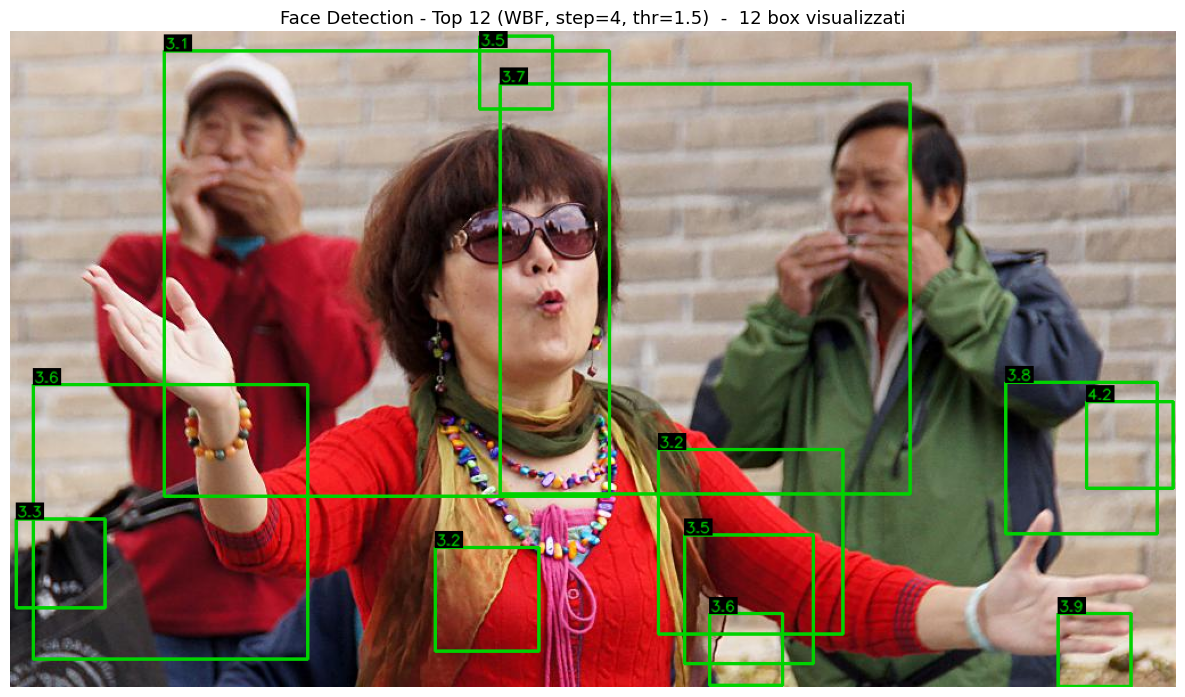


=== IMMAGINE 1 ===
  Detection grezze (score > 1.5, step=4): 4948
  Box dopo WBF:           760
  Box dopo containment:   57  (rimossi: 703)
  Box visualizzati (top 12): 12
  Score massimo: 3.58


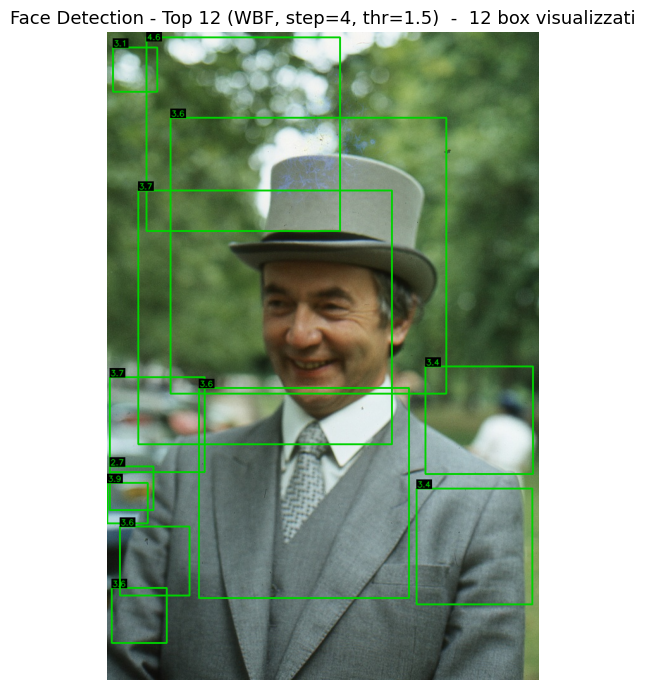


=== IMMAGINE 10 ===
  Detection grezze (score > 1.5, step=4): 3716
  Box dopo WBF:           494
  Box dopo containment:   41  (rimossi: 453)
  Box visualizzati (top 12): 12
  Score massimo: 3.52


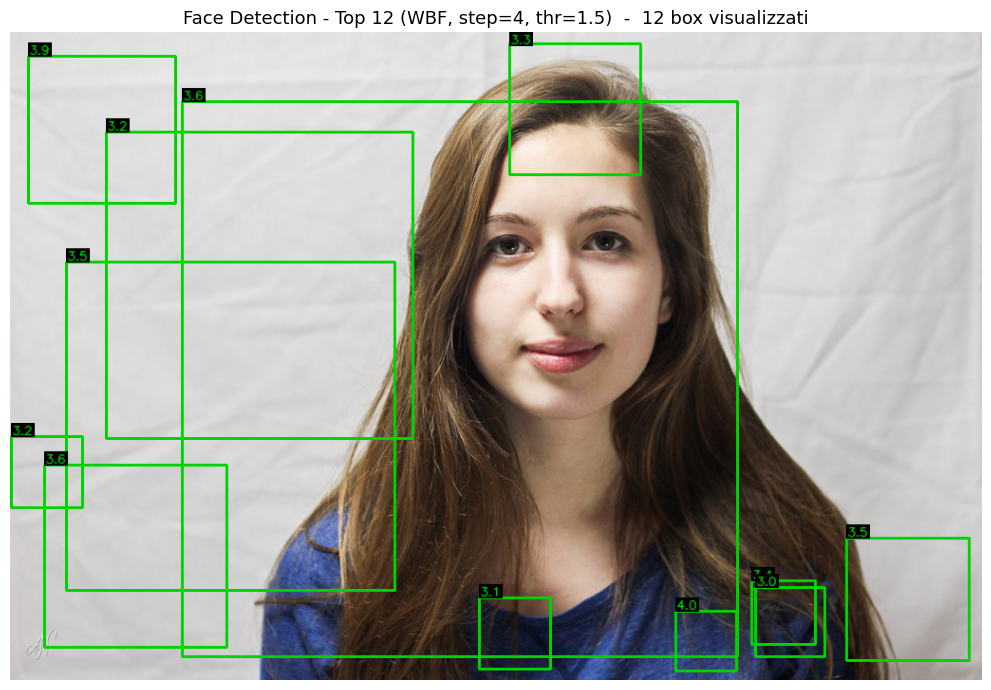

In [44]:
# Visualizzazione finale con modello HNM (meno falsi positivi) e pipeline WBF
run_detection_on_images(
    val_dataset,
    indices=[0, 1, 10],
    model=model_hnm,
    scaler=scaler_hnm,
    extract_hog=extract_hog,
    best_params=best_params,
    pixels_per_cell_map=pixels_per_cell_map,
    step_size=4,       # scansione fine per box piu' centrati sul volto
    threshold=1.5,   # alta confidenza
)


## 18. Valutazione finale sul TEST SET

Come test set si utilizza la porzione del validation dataset con indici **>= 2000** (filtrato con *max_faces=4*). Queste immagini **non sono mai state usate** in nessuna fase del progetto: nè nell'ottimizzazione con Optuna, nè nel training, nè per la scelta di *max_faces* o *threshold*.

Test set size: 2291 immagini

Feature test: (10358, 8100)
Distribuzione classi test - non-face: 6873  face: 3485

MODELLO BASE - TEST SET
CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.92      0.90      0.91      6873
           1       0.81      0.84      0.82      3485

    accuracy                           0.88     10358
   macro avg       0.86      0.87      0.86     10358
weighted avg       0.88      0.88      0.88     10358

[[6172  701]
 [ 569 2916]]


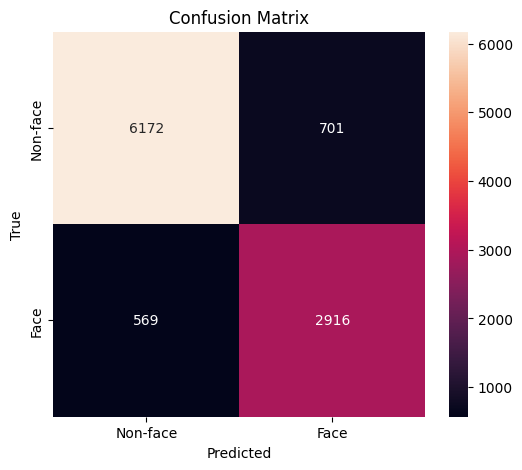


MODELLO HNM - TEST SET
CLASSIFICATION REPORT

              precision    recall  f1-score   support

           0       0.92      0.90      0.91      6873
           1       0.81      0.83      0.82      3485

    accuracy                           0.88     10358
   macro avg       0.86      0.87      0.87     10358
weighted avg       0.88      0.88      0.88     10358

[[6203  670]
 [ 576 2909]]


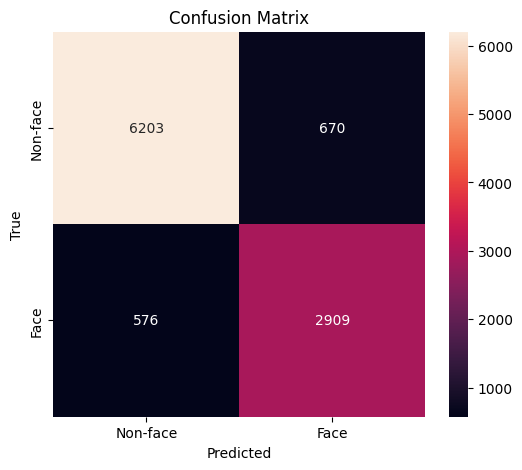

In [45]:
# Caricamento della porzione di validation set mai vista come test set
# Gli indici >= 2000 non sono mai stati usati in nessuna fase del progetto
test_dataset = load_annotations(
    val_images,
    val_labels,
    max_faces=4  # coerente con il filtro usato per training e validation
)
test_dataset = test_dataset[2000:]
print(f"Test set size: {len(test_dataset)} immagini")

# Costruzione delle feature HOG per il test set
X_test, y_test = build_hog_dataset(
    test_dataset,
    orientations=best_params["orientations"],
    pixels_per_cell=pixels_per_cell,
    cells_per_block=cells_per_block
)
print(f"\nFeature test: {X_test.shape}")
print(f"Distribuzione classi test - non-face: {np.bincount(y_test)[0]}  face: {np.bincount(y_test)[1]}")


# ===== Valutazione modello base =====
print("\n" + "=" * 55)
print("MODELLO BASE - TEST SET")
print("=" * 55)
classifier_report_confusion_matrix(model, scaler, X_test, y_test)

# ===== Valutazione modello HNM =====
print("\n" + "=" * 55)
print("MODELLO HNM - TEST SET")
print("=" * 55)
classifier_report_confusion_matrix(model_hnm, scaler_hnm, X_test, y_test)


VISUALIZZAZIONE - TEST SET

=== IMMAGINE 0 ===
  Detection grezze (score > 1.5, step=4): 5736
  Box dopo WBF:           882
  Box dopo containment:   59  (rimossi: 823)
  Box visualizzati (top 12): 12
  Score massimo: 6.92


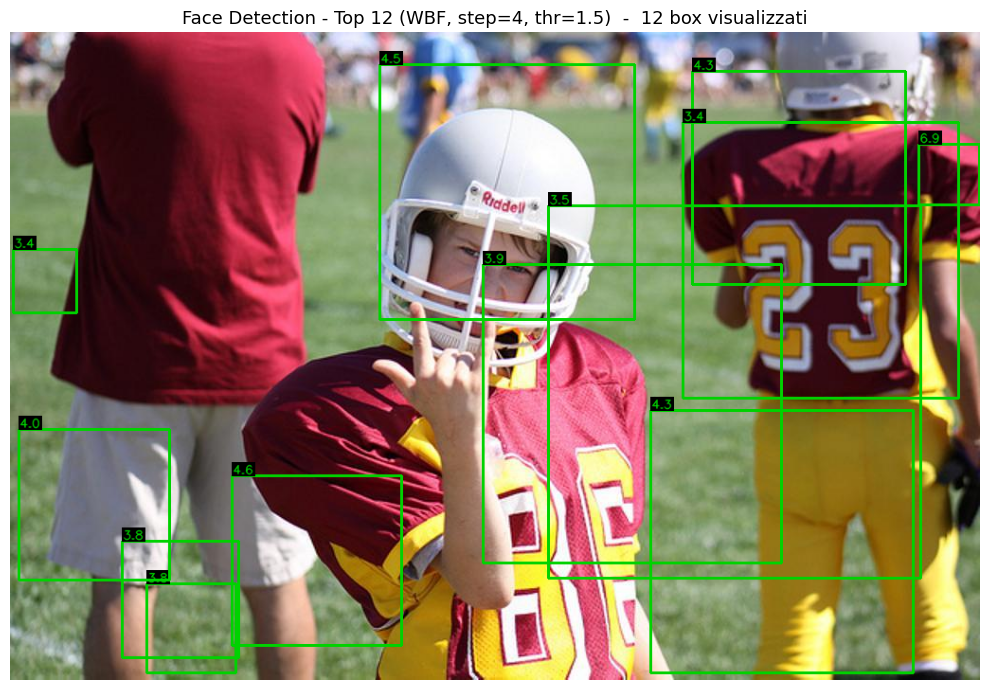


=== IMMAGINE 1 ===
  Detection grezze (score > 1.5, step=4): 4761
  Box dopo WBF:           668
  Box dopo containment:   31  (rimossi: 637)
  Box visualizzati (top 12): 12
  Score massimo: 3.98


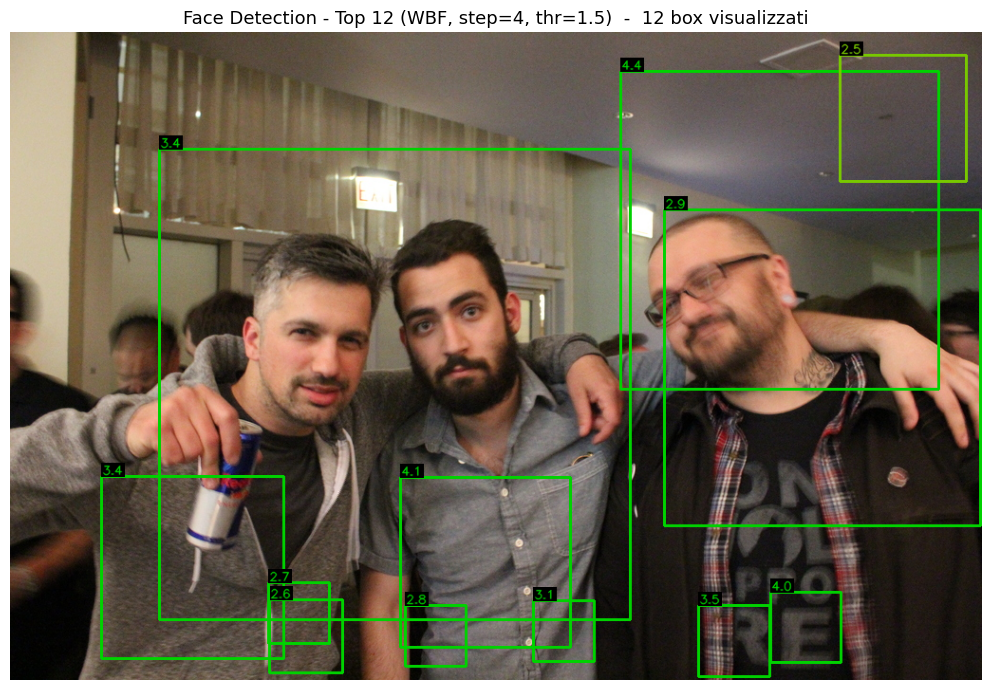

In [51]:
# ===== Visualizzazione detection su 2 immagini del test set =====
print("\n" + "=" * 55)
print("VISUALIZZAZIONE - TEST SET")
print("=" * 55)
run_detection_on_images(
    test_dataset,
    indices=[0, 1],
    model=model_hnm,
    scaler=scaler_hnm,
    extract_hog=extract_hog,
    best_params=best_params,
    pixels_per_cell_map=pixels_per_cell_map
)

**Interpretazione dei risultati sul test set**

Il confronto fra le metriche su validation e quelle su test mostra un gap molto ristretto: F1 macro **0.86** (validation, modello base) vs **0.86** (test base) e **0.87** (test HNM), con F1 face ~**0.82** su entrambi i modelli sul test set. Questo conferma che il modello generalizza correttamente e che le scelte di progettazione non hanno introdotto overfitting significativo.

Il modello ri-addestrato con Hard Negative Mining mantiene un lieve vantaggio rispetto al modello base anche sul test set (F1 macro **0.87** vs **0.86**). In particolare, si osserva una riduzione dei falsi positivi sulla classe "non-face", evidenziata dal numero inferiore di campioni negativi classificati erroneamente come positivi. Questo effetto è coerente con l'obiettivo dell'Hard Negative Mining, che mira a rafforzare il confine decisionale del classificatore nei casi più ambigui.

La visualizzazione qualitativa su immagini del test set (mai viste in precedenza) conferma il corretto funzionamento end-to-end della pipeline di detection. Nonostante un numero elevato di candidate window generate dalla sliding window, le fasi di filtraggio tramite soglia, Weighted Box Fusion e soppressione dei box ridondanti permettono di ottenere un numero finale di bounding box minore e più localizzato sui volti presenti.

# 19 Valutazione del detector con IoU vs ground truth

Nel punto precedente sono state analizzate le metriche del classification report, che misurano la capacità del modello di **classificare** patch HOG 64x64 etichettate come face/non-face.

A questo punto viene analizzata la capacità del modello come **detector**, cioè la capacità di localizzare correttamente i volti nell'immagine, non solo riconoscere patch isolate.

Vengono quindi confrontate le bounding box predette dal detector con le bounding box di ground truth del test set, usando le metriche standard del face detection:

- **IoU (Intersection over Union)**: misura quanto un box predetto si sovrappone a quello ground truth. Un detection viene considerato corretto se IoU >= 0.5.
- **Precision**: frazione di box predetti che corrispondono a un volto reale.
- **Recall**: frazione di volti reali rilevati correttamente.
- **F1**: media armonica delle precedenti.

**NOTA**. Per ragioni di costo computazionale (sliding window su image pyramid è lento: diversi secondi per immagine), la valutazione viene fatta su un sotto-campione di **10 immagini** del test set held-out. La valutazione è parallelizzata con joblib su tutti i core.


In [47]:
# VALUTAZIONE DETECTOR (Precision / Recall / F1)

def compute_iou_xywh(box_a, box_b):

    ax1, ay1, aw, ah = box_a
    bx1, by1, bw, bh = box_b

    ax2, ay2 = ax1 + aw, ay1 + ah
    bx2, by2 = bx1 + bw, by1 + bh

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    iw = max(0, inter_x2 - inter_x1)
    ih = max(0, inter_y2 - inter_y1)

    inter = iw * ih
    union = aw * ah + bw * bh - inter

    return inter / union if union > 0 else 0.0


def detector_report(
    dataset,
    model,
    scaler,
    extract_hog,
    best_params,
    pixels_per_cell_map,
    iou_thresh=0.5,
    score_thresh=1.5,
    overlap_thresh=0.3,
    contain_thresh=0.85,
    max_images=20,
    n_jobs=-1
):

    pixels_per_cell = pixels_per_cell_map[
        best_params["pixels_per_cell"]
    ]

    orientations = best_params["orientations"]
    cells_per_block = (2, 2)

    subset = dataset[:min(max_images, len(dataset))]

    print(
        f"Valutazione detector su "
        f"{len(subset)} immagini..."
    )

    def process_image(image_path, gt_boxes):

        image = cv2.imread(image_path)

        if image is None:
            return 0, 0, 0

        detections = detect_faces(
            image,
            model,
            scaler,
            extract_hog,
            orientations=orientations,
            pixels_per_cell=pixels_per_cell,
            cells_per_block=cells_per_block,
            threshold=score_thresh
        )

        if len(detections) > 0:

            detections = sorted(
                detections,
                key=lambda d: d[4],
                reverse=True
            )

            nms_boxes, nms_scores = non_max_suppression(
                [d[:4] for d in detections],
                [d[4] for d in detections],
                overlapThresh=overlap_thresh,
                return_scores=True
            )

            pred_boxes, _ = suppress_contained_boxes(
                nms_boxes,
                nms_scores,
                contain_thresh=contain_thresh
            )

        else:

            pred_boxes = []

        gt_used = [False] * len(gt_boxes)

        tp = 0
        fp = 0

        for pb in pred_boxes:

            best_iou = 0.0
            best_gt = -1

            for j, gb in enumerate(gt_boxes):

                if gt_used[j]:
                    continue

                iou = compute_iou_xywh(pb, gb)

                if iou > best_iou:
                    best_iou = iou
                    best_gt = j

            if best_iou >= iou_thresh:

                tp += 1
                gt_used[best_gt] = True

            else:

                fp += 1

        fn = sum(not x for x in gt_used)

        return tp, fp, fn

    results = Parallel(
        n_jobs=n_jobs,
        prefer="threads"
    )(
        delayed(process_image)(img, gt)
        for img, gt in subset
    )

    TP = sum(r[0] for r in results)
    FP = sum(r[1] for r in results)
    FN = sum(r[2] for r in results)

    precision = (
        TP / (TP + FP)
        if (TP + FP) > 0 else 0
    )

    recall = (
        TP / (TP + FN)
        if (TP + FN) > 0 else 0
    )

    f1 = (
        2 * precision * recall /
        (precision + recall)
        if (precision + recall) > 0 else 0
    )

    print(f"TP: {TP}")
    print(f"FP: {FP}")
    print(f"FN: {FN}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

    return {
        "precision": precision,
        "recall": recall,
        "f1": f1
    }



# CONFRONTO DETECTOR BASE vs HNM

print("DETECTOR BASE")

det_base = detector_report(
    test_dataset,
    model,
    scaler,
    extract_hog,
    best_params,
    pixels_per_cell_map,
    max_images=10
)


print("DETECTOR HNM")

det_hnm = detector_report(
    test_dataset,
    model_hnm,
    scaler_hnm,
    extract_hog,
    best_params,
    pixels_per_cell_map,
    max_images=10
)


print("CONFRONTO FINALE")

print(
    f"Base -> "
    f"P={det_base['precision']:.4f}  "
    f"R={det_base['recall']:.4f}  "
    f"F1={det_base['f1']:.4f}"
)

print(
    f"HNM  -> "
    f"P={det_hnm['precision']:.4f}  "
    f"R={det_hnm['recall']:.4f}  "
    f"F1={det_hnm['f1']:.4f}"
)

DETECTOR BASE
Valutazione detector su 10 immagini...
TP: 3
FP: 451
FN: 15
Precision: 0.0066
Recall:    0.1667
F1-score:  0.0127
DETECTOR HNM
Valutazione detector su 10 immagini...
TP: 4
FP: 477
FN: 14
Precision: 0.0083
Recall:    0.2222
F1-score:  0.0160
CONFRONTO FINALE
Base -> P=0.0066  R=0.1667  F1=0.0127
HNM  -> P=0.0083  R=0.2222  F1=0.0160


**Interpretazione: classificatore vs detector**

Confrontando le metriche di **classificazione** (sezione 13) con quelle di **detection** (questa sezione) emerge una distinzione importante:

- **F1 classificatore** (patch 64×64): **~0.86** (base) e **~0.91** (HNM) sul validation set;
- **F1 detector** (IoU ≥ 0.5, 10 immagini test): **0.013** (Base) e **0.016** (HNM).

La differenza di performance tra i due livelli è attesa per un detector classico HOG+SVM e dipende da:

1. **Sliding window a passi discreti**: lo step di 8 px e il fattore piramide 1.2 introducono un disallineamento intrinseco fra finestra e volto reale (raramente il volto è perfettamente centrato in una finestra 64x64);
2. **Box di forma fissa**: il rapporto altezza/larghezza è fisso a 1:1, quindi i volti molto allungati o larghi ricevono un box meno aderente;
3. **Soglia IoU=0.5 è rigida**: anche una predizione visivamente "buona" può avere IoU appena sotto 0.5 e venire scartata;
4. **Amplificazione degli errori**: anche con un classificatore accurato, migliaia di finestre per immagine moltiplicano i falsi positivi (su 10 immagini: **451 FP** base, **477 FP** HNM, vs **3–4 TP**).

Il modello **HNM**, già migliore a livello di classificazione patch, mostra un lieve vantaggio anche a livello di detector: precision **0.0083** vs **0.0066** e recall **0.22** vs **0.17** sul campione valutato.

Per migliorare significativamente queste metriche servirebbe passare a un approccio di Deep Learning che apprende direttamente la regression delle bounding box.


# 20. Limiti del metodo HOG + SVM

La pipeline implementata **HOG feature extraction + LinearSVC + sliding window con image pyramid** produce risultati accettabili su immagini con 1-3 volti ben illuminati e frontali, ma presenta limitazioni strutturali che non possono essere superate senza cambiare paradigma di programmazione.

Limiti osservati:

1. **Box multipli sullo stesso volto.** Anche dopo NMS e soppressione dei box contenuti, la piramide multi-scala produce frequentemente molti candidati concentrici per uno stesso volto. Le soglie di NMS e containment vanno calibrate con compromessi tra recall (mantenere quanti volti possibile) e precision (eliminare i duplicati).

2. **Falsi positivi su sfondi complessi.** Anche con un classificatore a F1 macro ~**0.91** (HNM), una piccola frazione di errori si traduce in centinaia di falsi positivi a livello di detector (texture di tessuti, foglie, mattoni che assomigliano a un volto).

3. **Finestra fissa 64x64.** HOG è applicato su patch quadrate. I volti molto allungati (laterali, di profilo) o con ornamenti significativi vengono coperti meno bene.

4. **Nessun contesto spaziale.** Ogni patch viene classificata indipendentemente. Il modello non sa che gli "occhi" devono essere sopra il "naso" che deve essere sopra la "bocca" - sa solo che la combinazione di gradienti deve assomigliare al training.

5. **Costo computazionale.** Sliding window + image pyramid scansiona migliaia di posizioni per immagine. Per ogni patch: preprocessing + HOG (~1764 feature) + scaling + SVM. Inference può impiegare diversi secondi per una singola foto in risoluzione media.

Questi limiti possono essere superati con il Deep Learning, che generalmente gestisce meglio variazioni di scala, illuminazione e contesto, e riduce la necessità di progettare manualmente le feature o di utilizzare pipeline multi-step come sliding window e image pyramid.